# Magnetic Field Evolution in Satellite Galaxies
## PHY 225-001 — Computational Physics Project

**Goal:** Track magnetic field strength as a function of redshift for satellite galaxies in TNG100, using merger tree data to identify the moment of central-to-satellite transition (infall time), then apply kernel smoothing to extract clean trends.

---
### Notebook Structure
1. Setup & Imports
2. Build Snapshot → Redshift / Lookback-Time Table
3. Query Satellite Galaxies at z=0
4. Walk the Merger Tree (main progenitor branch)
5. Identify Infall Time (central → satellite transition)
6. Plot Raw B-field vs Redshift
7. Generalize to Multiple Galaxies
8. Kernel Smoothing + LOOCV Bandwidth Selection
9. Smoothed B-field vs Time Since Infall (Key Science Plot)
10. Fit Exponential Growth Model

---
## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import pickle
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

# Make sure iapi.py is in the same directory as this notebook
import iapi

# TNG100 cosmological parameters (Planck 2015)
cosmo    = FlatLambdaCDM(H0=67.74, Om0=0.3089)
SIM_NAME = 'TNG100-1'
h_cosmo  = 0.6774

# Make sure output folders exist
#os.makedirs('trees', exist_ok=True)
#os.makedirs('results/figures', exist_ok=True)
#os.makedirs('data/processed', exist_ok=True)
import pathlib
repo_root = pathlib.Path.cwd().parent # Go up from notebooks/ to repo root
os.makedirs(repo_root / 'trees', exist_ok=True)
os.makedirs(repo_root / 'results' / 'figures', exist_ok=True)
os.makedirs(repo_root / 'data' / 'processed', exist_ok=True)

# Quick connectivity test
try:
    info = iapi.get(iapi.baseUrl + SIM_NAME + '/')
    print(f'Connected to {SIM_NAME}')
    print(f'Available keys: {list(info.keys())}')
except Exception as e:
    print(f'Connection failed: {e}')

Connected to TNG100-1
Available keys: ['name', 'description', 'name_alt', 'boxsize', 'z_start', 'z_final', 'cosmology', 'omega_0', 'omega_L', 'omega_B', 'hubble', 'physics_model', 'has_cooling', 'has_starformation', 'has_winds', 'has_blackholes', 'mass_gas', 'mass_dm', 'softening_dm_comoving', 'softening_stars_comoving', 'softening_blackholes_comoving', 'softening_gas_comoving', 'softening_dm_max_phys', 'softening_stars_max_phys', 'softening_blackholes_max_phys', 'softening_gas_max_phys', 'softening_gas_factor', 'softening_gas_comoving_min', 'num_dm', 'num_tr_mc', 'num_tr_vel', 'longids', 'is_uniform', 'is_zoom', 'is_subbox', 'num_files_snapshot', 'num_files_groupcat', 'num_files_rockstar', 'num_files_lhalotree', 'num_files_sublink', 'num_files_ctrees', 'filesize_lhalotree', 'filesize_sublink', 'filesize_ctrees', 'filesize_ics', 'filesize_simulation', 'has_fof', 'has_subfind', 'has_rockstar', 'has_lhalotree', 'has_sublink', 'has_ctrees', 'permission_required', 'num_snapshots', 'url', '

---
## 2. Build the Snapshot → Redshift / Lookback-Time Table

In [2]:
def build_snapshot_table(sim_name=SIM_NAME):
    """
    Return a dict mapping snapshot number -> {redshift, scale_factor, lookback_time_Gyr}.
    Uses astropy FlatLambdaCDM for the lookback time integral.
    """
    snaps_info = iapi.get(iapi.baseUrl + sim_name + '/snapshots/')
    table = {}
    for s in snaps_info:
        z  = s['redshift']
        lb = cosmo.lookback_time(z).to(u.Gyr).value
        table[s['number']] = {
            'redshift'      : z,
            'scale_factor'  : 1.0 / (1.0 + z),
            'lookback_time' : lb,
        }
    return table


SNAP_TABLE = build_snapshot_table()

print(f"{'Snap':>5}  {'z':>8}  {'a':>8}  {'Lookback (Gyr)':>15}")
print('-' * 45)
for sn in [0, 10, 33, 50, 67, 78, 91, 99]:
    row = SNAP_TABLE[sn]
    print(f"{sn:>5}  {row['redshift']:>8.3f}  {row['scale_factor']:>8.4f}  {row['lookback_time']:>15.3f}")

 Snap         z         a   Lookback (Gyr)
---------------------------------------------
    0    20.046    0.0475           13.623
   10     7.236    0.1214           13.071
   33     2.002    0.3331           10.518
   50     0.997    0.5007            7.925
   67     0.503    0.6653            5.216
   78     0.298    0.7706            3.504
   91     0.099    0.9096            1.336
   99     0.000    1.0000            0.000


---
## 3. Query Satellite Galaxies at z = 0

In [3]:
def query_satellites(snap=99, stellar_mass_min_log=9.5, stellar_mass_max_log=11.5,
                     limit=20, grnr=None):
    """
    Return satellite subhalos from a given snapshot.
    grnr: if set, only return satellites belonging to that FoF group number.
          Set grnr=0 to get satellites of the most massive halo in the simulation.
    """
    url    = iapi.baseUrl + SIM_NAME + f'/snapshots/{snap}/subhalos/'
    params = {
        'primary_flag'      : 0,
        'mass_log_msun__gte': stellar_mass_min_log,
        'mass_log_msun__lte': stellar_mass_max_log,
        'limit'             : limit,
    }
    if grnr is not None:
        params['SubhaloGrNr'] = grnr

    result   = iapi.get(url, params=params)
    galaxies = result.get('results', [])
    print(f"Found {result['count']} satellites in group {grnr}; returning {len(galaxies)}.")
    return galaxies


# Pull satellites of the most massive halo (SubhaloGrNr = 0)
satellites_z0 = query_satellites(snap=99, stellar_mass_min_log=8.0, grnr=0, limit=50)

print(f"\n{'#':>3}  {'SubhaloID':>10}  {'log M*':>8}")
print('-' * 28)
for i, g in enumerate(satellites_z0):
    print(f"{i:>3}  {g['id']:>10d}  {g['mass_log_msun']:>8.3f}")

Found 940505 satellites in group 0; returning 50.

  #   SubhaloID    log M*
----------------------------
  0           1    13.733
  1           2    13.058
  2           3    12.700
  3           4    12.682
  4           5    12.643
  5           6    12.485
  6           7    12.308
  7           8    12.243
  8           9    12.280
  9          10    12.184
 10          11    11.835
 11          12    12.234
 12          13    12.185
 13          14    11.982
 14          15    12.181
 15          16    12.124
 16          17    12.037
 17          18    11.987
 18          19    11.746
 19          20    11.977
 20          21    11.618
 21          22    11.927
 22          23    11.476
 23          24    11.777
 24          25    11.702
 25          26    11.765
 26          27    11.774
 27          28    11.746
 28          29    11.781
 29          30    11.653
 30          31    11.318
 31          32    11.606
 32          33    11.616
 33          34    11.473
 34       

---
## 4. Walk the Merger Tree — Main Progenitor Branch

We use `iapi.gettree()` to download and cache the MPB HDF5 file per galaxy.

**Note on 403 errors:** If you get a 403 for a subhalo, the code prints the URL to check in your browser. Some subhalos have no merger tree and are automatically skipped.

**Fields extracted from the tree HDF5:**

| Field | Description |
|---|---|
| `SnapNum` | Snapshot number |
| `SubhaloBfldDisk` | Mass-weighted B-field in disk (comoving Gauss) |
| `SubhaloBfldHalo` | Mass-weighted B-field in halo (comoving Gauss) |
| `SubhaloMassType` | Mass by particle type (index 4 = stellar) |
| `GroupFirstSub` | ID of the primary subhalo of the host FoF group |
| `SubfindID` | The subhalo's own ID at that snapshot |

> **Unit conversion:** $B_{\rm phys} = B_{\rm com} / a^2$ where $a = 1/(1+z)$

In [4]:
def get_mpb(subhalo_id, snap=99):
    """
    Download the Main Progenitor Branch for a subhalo using iapi.gettree().
    Returns a list of dicts, one per snapshot (z=0 first, high-z last).
    Prints a browser URL if a 403 error is encountered.
    """
    try:
        tree_file = iapi.gettree(str(snap), subhalo_id)
    except Exception as e:
        print(f'  FAILED — check this URL in your browser:')
        print(f'  https://www.tng-project.org/api/TNG100-1/snapshots/{snap}/subhalos/{subhalo_id}/')
        raise e

    records = []
    with h5py.File(tree_file, 'r') as f:
        snaps     = f['SnapNum'][:]
        B_disk    = f['SubhaloBfldDisk'][:]
        B_halo    = f['SubhaloBfldHalo'][:]
        masses    = f['SubhaloMassType'][:]   # shape (N, 6)
        sub_ids   = f['SubfindID'][:]
        grp_first = f['GroupFirstSub'][:]

        for i in range(len(snaps)):
            sn = int(snaps[i])
            sd = SNAP_TABLE.get(sn, {})
            records.append({
                'snap'            : sn,
                'redshift'        : sd.get('redshift', np.nan),
                'lookback_time'   : sd.get('lookback_time', np.nan),
                'scale_factor'    : sd.get('scale_factor', np.nan),
                'B_disk'          : float(B_disk[i]),
                'B_halo'          : float(B_halo[i]),
                'M_star'          : float(masses[i][4]) * 1e10 / h_cosmo,
                'subfind_id'      : int(sub_ids[i]),
                'group_first_sub' : int(grp_first[i]),
            })
    return records


def compute_B_physical(records):
    """
    Convert comoving B-fields to physical Gauss: B_phys = B_com / a^2.
    Adds B_disk_phys and B_halo_phys to each record.
    """
    for r in records:
        a = r['scale_factor']
        if a > 0:
            r['B_disk_phys'] = r['B_disk'] / a**2
            r['B_halo_phys'] = r['B_halo'] / a**2
        else:
            r['B_disk_phys'] = np.nan
            r['B_halo_phys'] = np.nan
    return records


# Test on the first available satellite
# Change TEST_INDEX if you get a 403 error
TEST_INDEX = 3
test_id    = satellites_z0[TEST_INDEX]['id']
print(f'Testing with satellites_z0[{TEST_INDEX}]: SubhaloID = {test_id}')

mpb_data = get_mpb(test_id)
mpb_data = compute_B_physical(mpb_data)

print(f'\nMPB for SubhaloID {test_id}: {len(mpb_data)} snapshots')
print(f"{'Snap':>5}  {'z':>7}  {'B_disk_phys':>13}  {'B_halo_phys':>13}  {'log M*':>8}")
print('-' * 55)
for r in mpb_data[:8]:
    logM = np.log10(r['M_star']) if r['M_star'] > 0 else np.nan
    print(f"{r['snap']:>5}  {r['redshift']:>7.3f}  "
          f"{r['B_disk_phys']:>13.4e}  {r['B_halo_phys']:>13.4e}  {logM:>8.2f}")

Testing with satellites_z0[3]: SubhaloID = 4

MPB for SubhaloID 4: 98 snapshots
 Snap        z    B_disk_phys    B_halo_phys    log M*
-------------------------------------------------------
   99    0.000     4.1119e-04            nan     11.12
   98    0.010     5.5222e-03            nan     11.12
   97    0.024     5.9134e-03            nan     11.12
   96    0.034     2.5428e-03     4.9489e-03     11.12
   95    0.049     1.4898e-03            nan     11.12
   94    0.059     2.6831e-03     3.0896e-03     11.12
   93    0.074     6.1452e-04            nan     11.12
   92    0.084     2.3561e-03            nan     11.12


---
## 5. Identify Infall Time (Central → Satellite Transition)

A galaxy is a **central** at snapshot $n$ if `SubfindID[n] == GroupFirstSub[n]`.
We walk the MPB from z=0 backward and find the last snapshot where it was a central.
The infall snapshot is one step forward in time from that.

In [5]:
def find_infall_snap(mpb_records):
    """
    Identify the snapshot of central -> satellite transition.
    MPB is ordered z=0 -> high-z (index 0 is z=0).
    Returns a dict with snap, redshift, lookback_time -- or None if not found.
    """
    was_central_at = None
    for i, r in enumerate(mpb_records):
        if r['subfind_id'] == r['group_first_sub']:
            was_central_at = i

    if was_central_at is None or was_central_at == 0:
        return None

    infall_record = mpb_records[was_central_at - 1]
    return {
        'snap'         : infall_record['snap'],
        'redshift'     : infall_record['redshift'],
        'lookback_time': infall_record['lookback_time'],
    }


# Test on the single test galaxy
infall = find_infall_snap(mpb_data)

if infall:
    print(f"Infall snapshot : {infall['snap']}")
    print(f"Infall redshift : z = {infall['redshift']:.3f}")
    print(f"Infall lookback : {infall['lookback_time']:.2f} Gyr ago")
else:
    print('Could not determine infall time for this galaxy.')

Infall snapshot : 2
Infall redshift : z = 11.980
Infall lookback : 13.43 Gyr ago


---
## 6. Plot Raw B-field vs Redshift

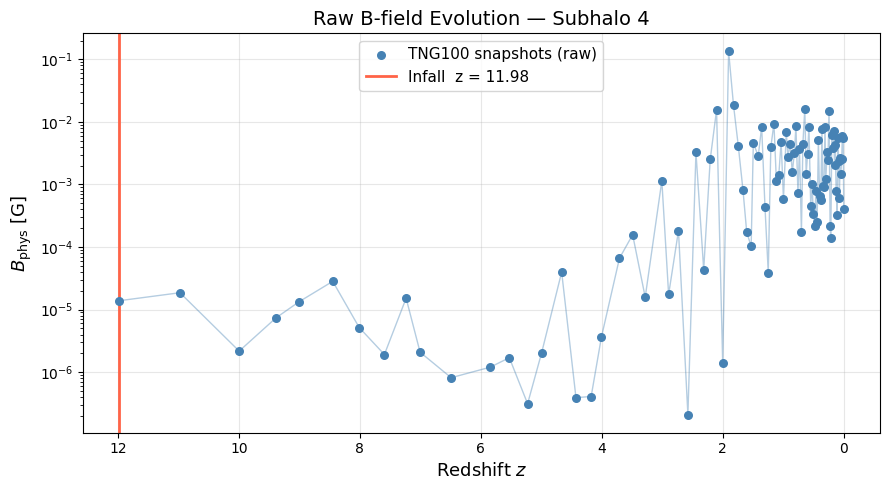

In [6]:
def plot_B_vs_redshift_single(mpb_records, infall_info=None, subhalo_id=None,
                              field='B_disk_phys'):
    """
    Plot raw B-field vs redshift for a single galaxy's MPB.
    Marks the infall redshift with a vertical line.
    """
    valid  = [r for r in mpb_records if np.isfinite(r[field]) and r[field] > 0]
    z_arr  = np.array([r['redshift'] for r in valid])
    B_arr  = np.array([r[field]      for r in valid])
    order  = np.argsort(z_arr)
    z_arr, B_arr = z_arr[order], B_arr[order]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(z_arr, B_arr, s=30, color='steelblue', zorder=3, label='TNG100 snapshots (raw)')
    ax.plot(z_arr, B_arr, color='steelblue', alpha=0.4, lw=1)

    if infall_info:
        ax.axvline(infall_info['redshift'], color='tomato', lw=2,
                   label=f"Infall  z = {infall_info['redshift']:.2f}")

    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=13)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=13)
    ax.set_title(f'Raw B-field Evolution — Subhalo {subhalo_id}', fontsize=14)
    ax.invert_xaxis()
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    #plt.savefig(f'results/figures/B_vs_z_subhalo_{subhalo_id}.png', dpi=150)
    plt.savefig(repo_root / f'results/figures/B_vs_z_subhalo_{subhalo_id}.png', dpi=150)
    plt.show()


def plot_B_vs_redshift_all(all_galaxies, field='B_disk_phys'):
    """
    Overlay raw B-field vs redshift for all galaxies, color-coded by infall redshift.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    infalls = [g['infall']['redshift'] for g in all_galaxies if g['infall']]
    if not infalls:
        print('No galaxies with infall times found.')
        return
    norm = plt.Normalize(vmin=min(infalls), vmax=max(infalls))
    cmap = plt.cm.plasma

    for gal in all_galaxies:
        mpb    = gal['mpb']
        infall = gal['infall']
        valid  = [r for r in mpb if np.isfinite(r.get(field, np.nan)) and r[field] > 0]
        if not valid:
            continue
        z_arr = np.array([r['redshift'] for r in valid])
        B_arr = np.array([r[field]      for r in valid])
        order = np.argsort(z_arr)
        color = cmap(norm(infall['redshift'])) if infall else 'gray'
        ax.plot(z_arr[order], B_arr[order], color=color, alpha=0.5, lw=1.2)
        if infall:
            ax.axvline(infall['redshift'], color=color, lw=0.5, ls=':', alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Infall redshift $z_{\\rm infall}$')

    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=13)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=13)
    ax.set_title(f'Raw B-field Evolution — All Satellites (N={len(all_galaxies)})', fontsize=14)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    #plt.savefig('results/figures/B_vs_z_all_raw.png', dpi=150)
    plt.savefig(repo_root / f'results/figures/B_vs_z_subhalo_{subhalo_id}.png', dpi=150)
    plt.show()


# Plot the single test galaxy
plot_B_vs_redshift_single(mpb_data, infall_info=infall, subhalo_id=test_id)

---
## 7. Generalize to Multiple Galaxies

In [7]:
def process_all_satellites(satellite_list):
    """
    For each satellite, fetch MPB, compute physical B-field, and find infall.
    Skips satellites that return 403/404 errors.
    Returns a list of dicts: {subhalo_id, mpb, infall}
    """
    results = []
    for i, gal in enumerate(satellite_list):
        sid = gal['id']
        print(f'[{i+1}/{len(satellite_list)}] SubhaloID {sid} ...', end=' ')
        try:
            mpb    = get_mpb(sid)
            mpb    = compute_B_physical(mpb)
            infall = find_infall_snap(mpb)
            results.append({'subhalo_id': sid, 'mpb': mpb, 'infall': infall})
            status = f"infall z={infall['redshift']:.2f}" if infall else 'no infall found'
            print(f'OK ({status})')
        except Exception as e:
            print(f'SKIPPED: {e}')
    print(f'\nProcessed  : {len(results)} galaxies')
    print(f'With infall: {sum(1 for g in results if g["infall"])}')
    return results


# Load from cache if available, otherwise download
#cache = 'data/processed/all_galaxies.pkl'
cache = repo_root / 'data' / 'processed' / 'all_galaxies.pkl'
if os.path.exists(cache):
    with open(cache, 'rb') as f:
        all_galaxies = pickle.load(f)
    print(f'Loaded {len(all_galaxies)} galaxies from cache.')
else:
    all_galaxies = process_all_satellites(satellites_z0)
    with open(cache, 'wb') as f:
        pickle.dump(all_galaxies, f)
    print(f'Saved {len(all_galaxies)} galaxies to cache.')

Loaded 50 galaxies from cache.


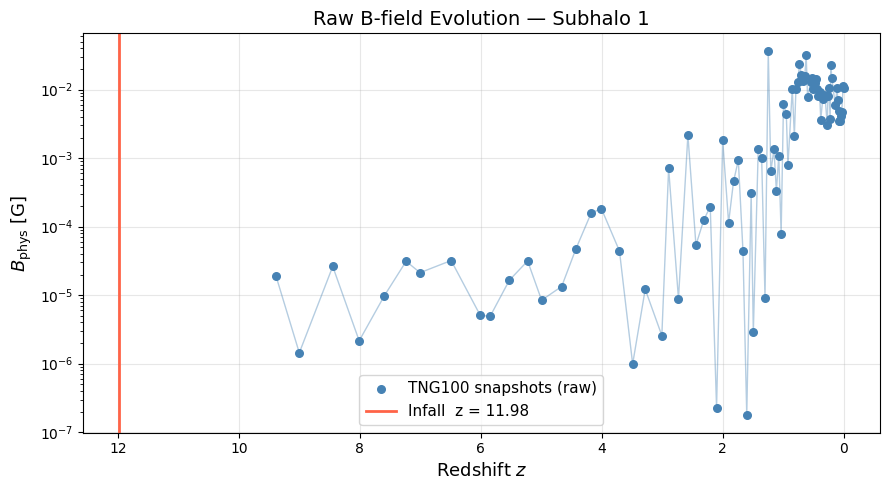

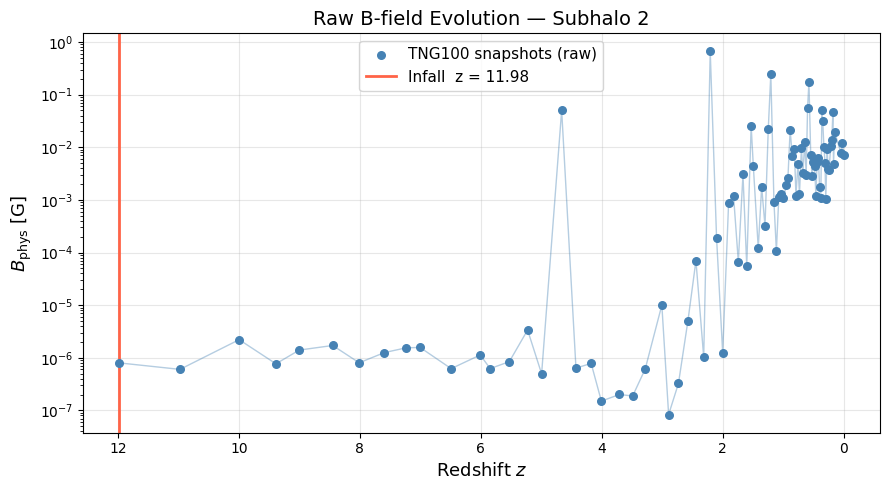

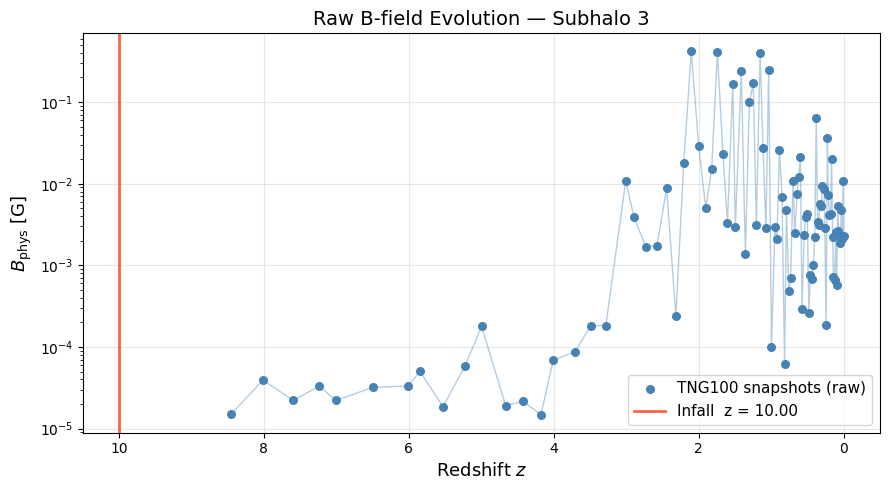

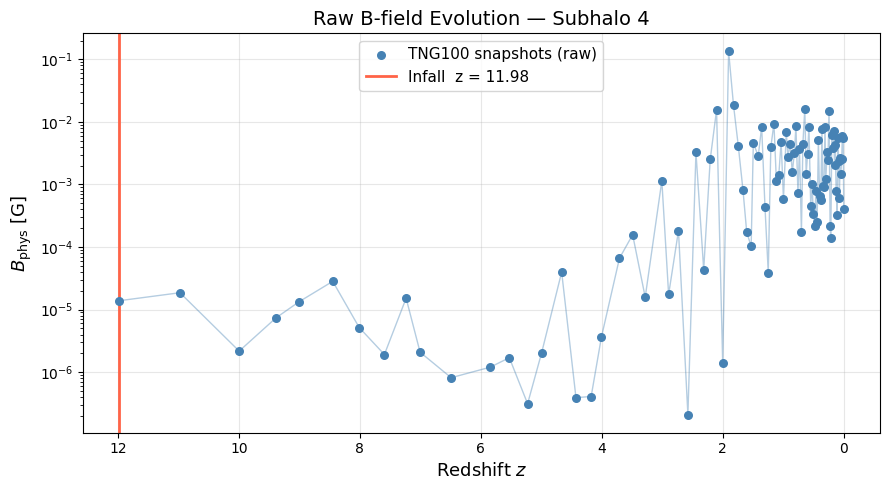

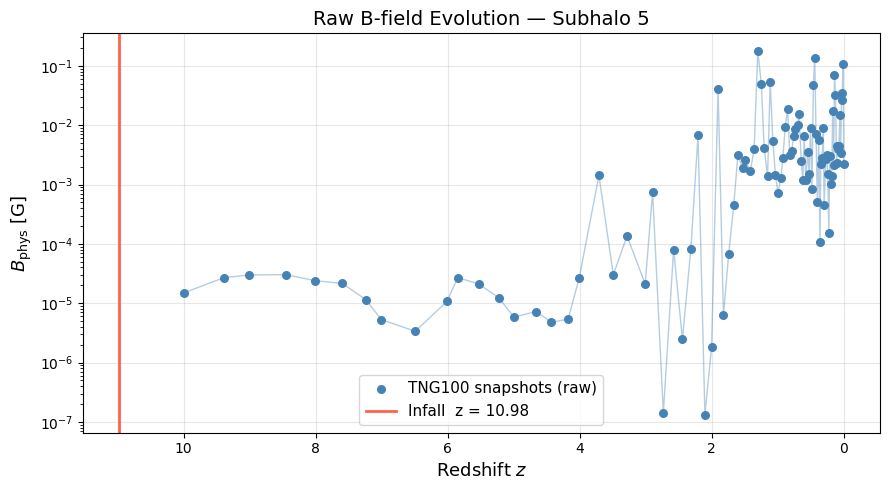

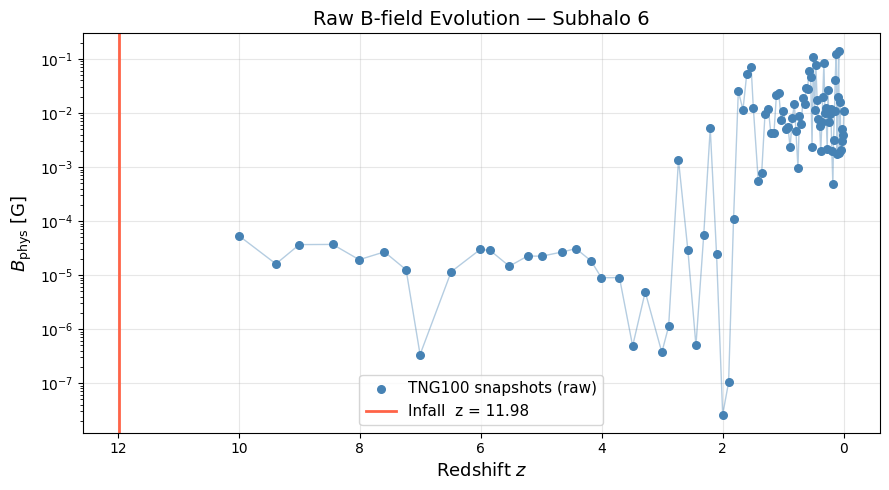

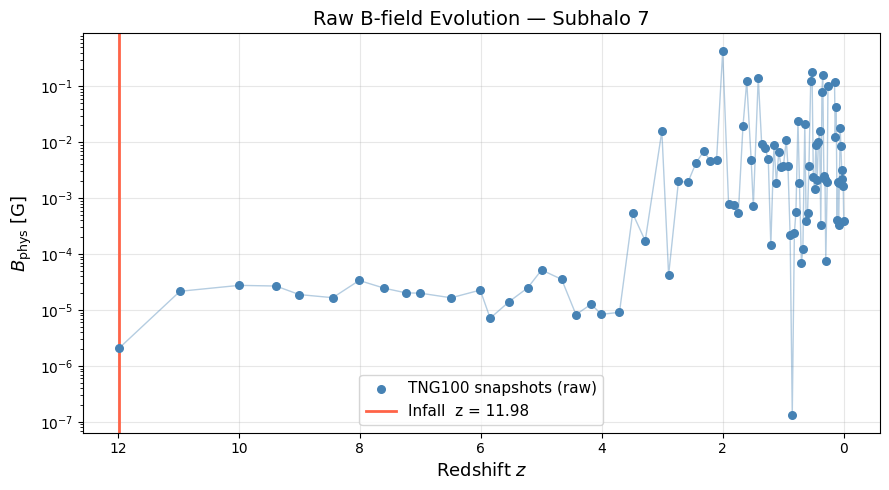

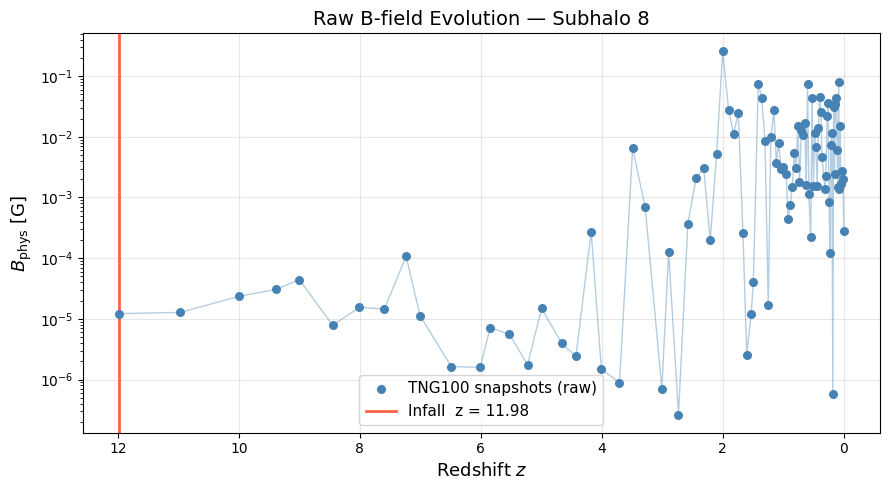

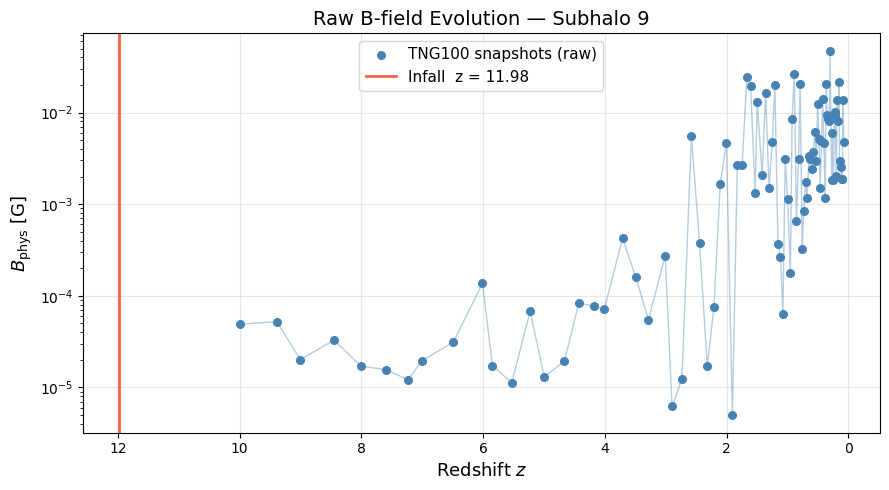

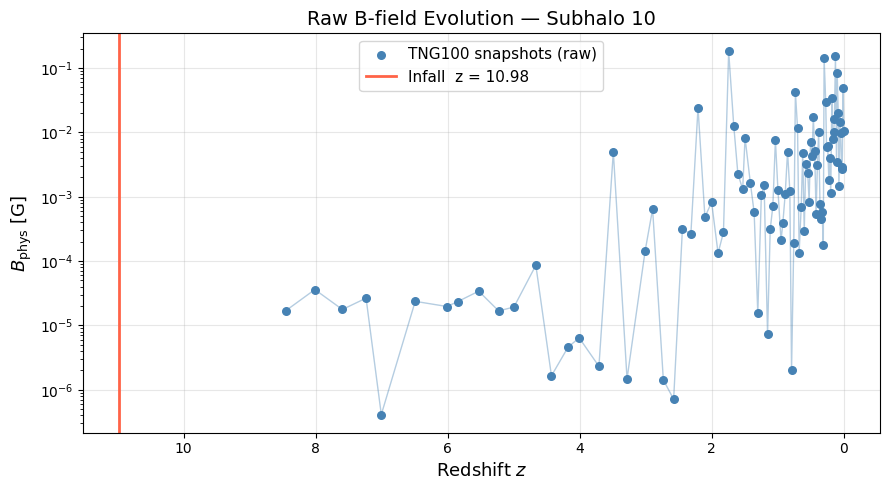

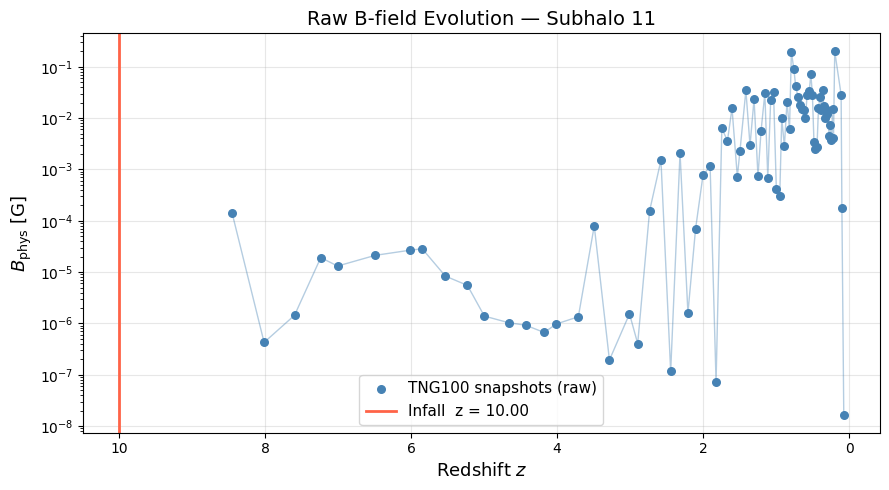

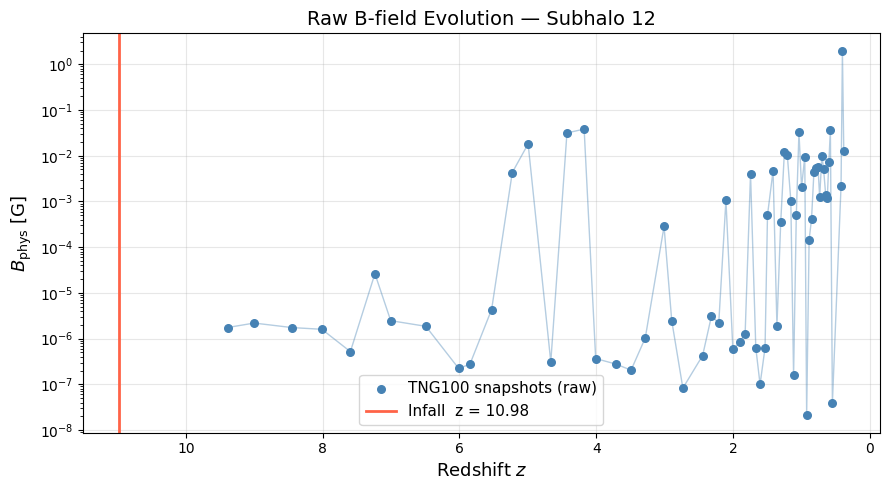

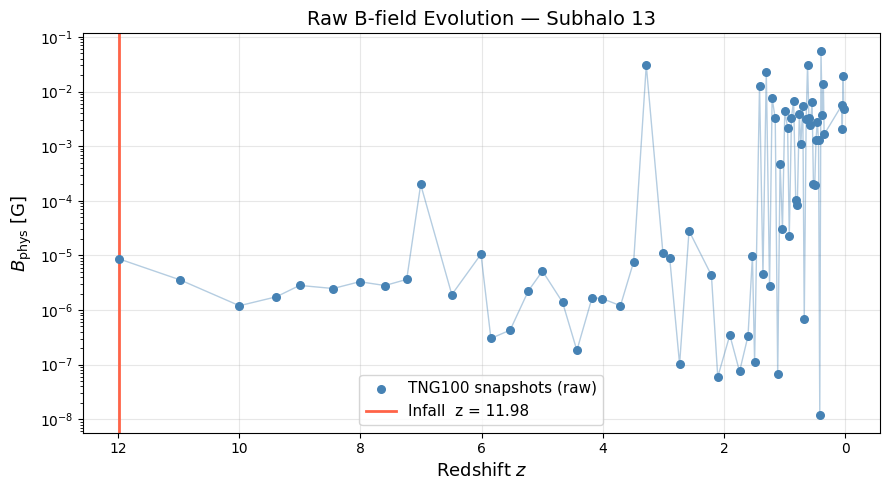

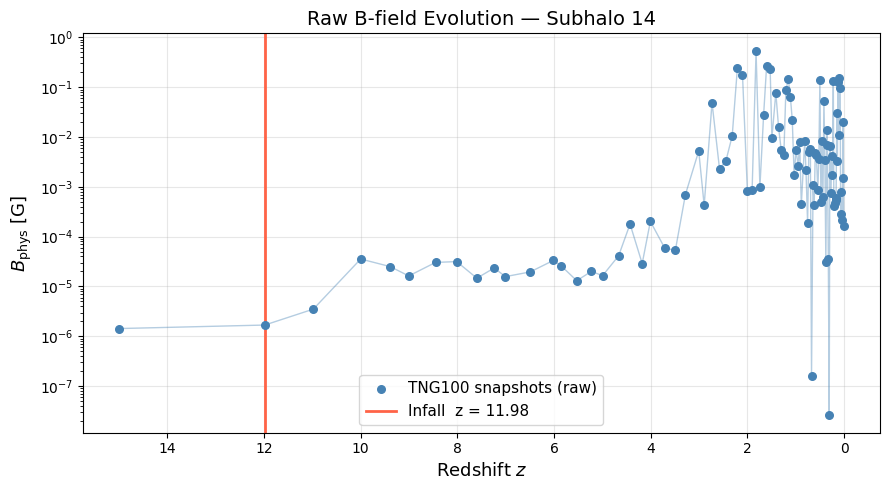

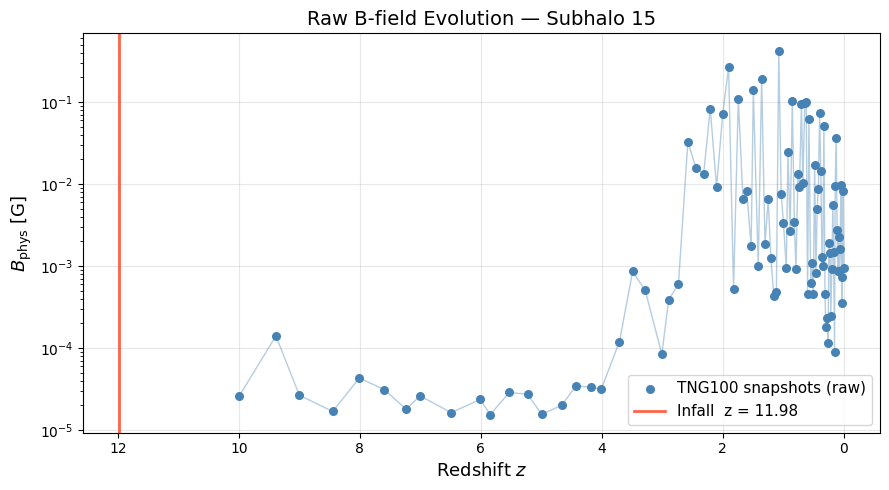

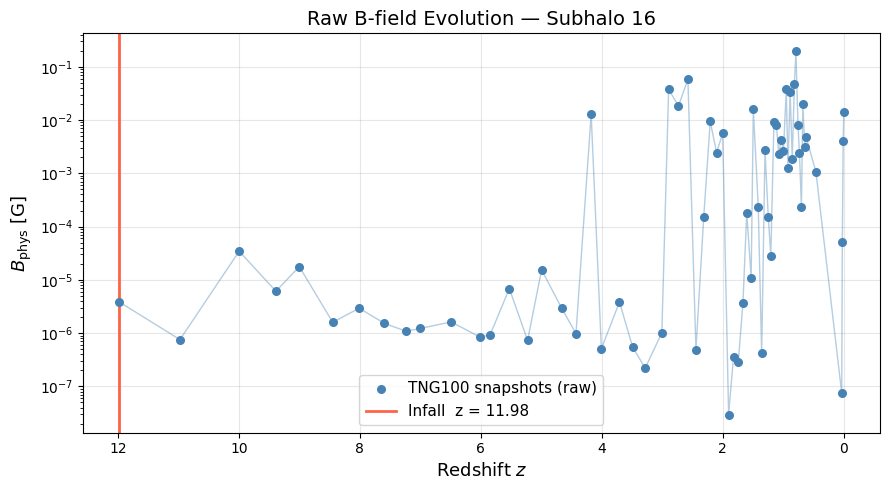

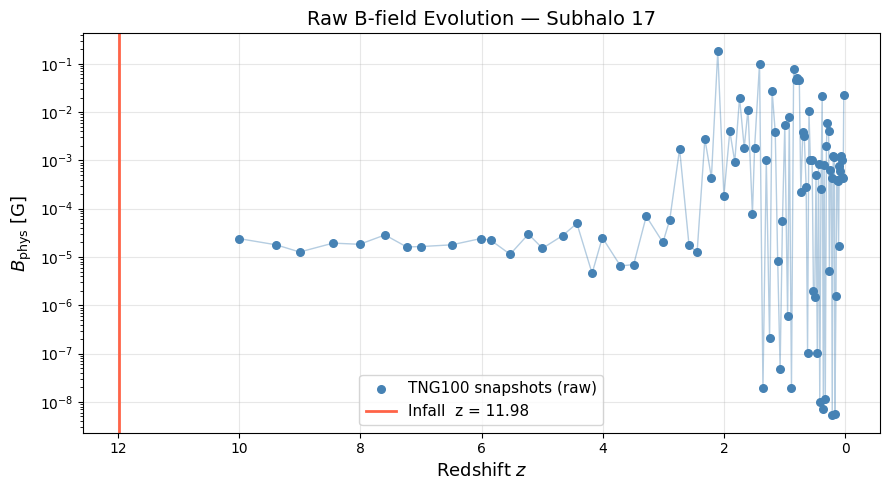

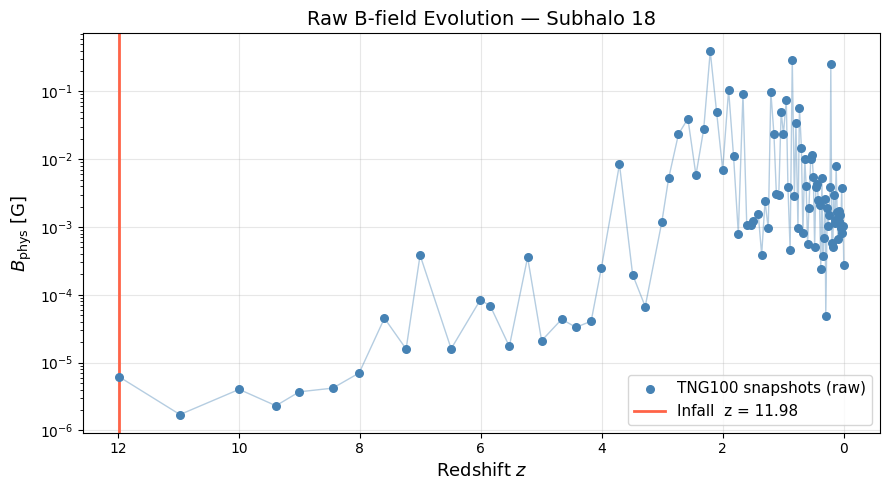

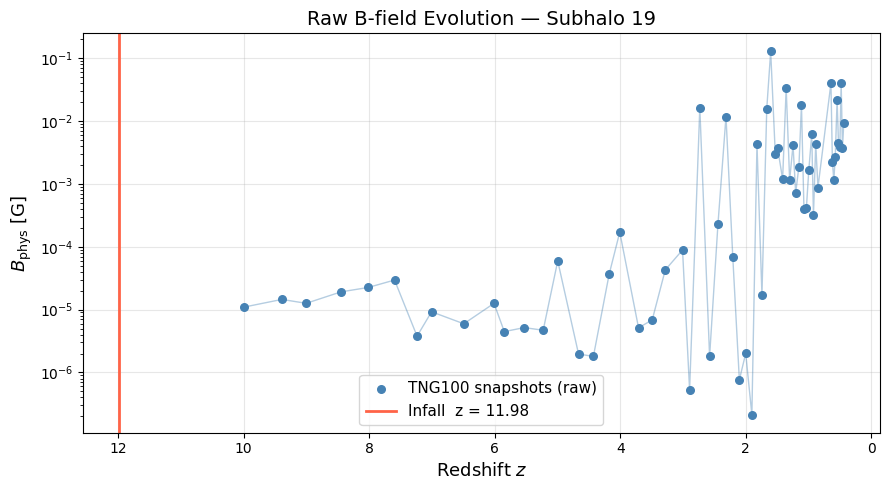

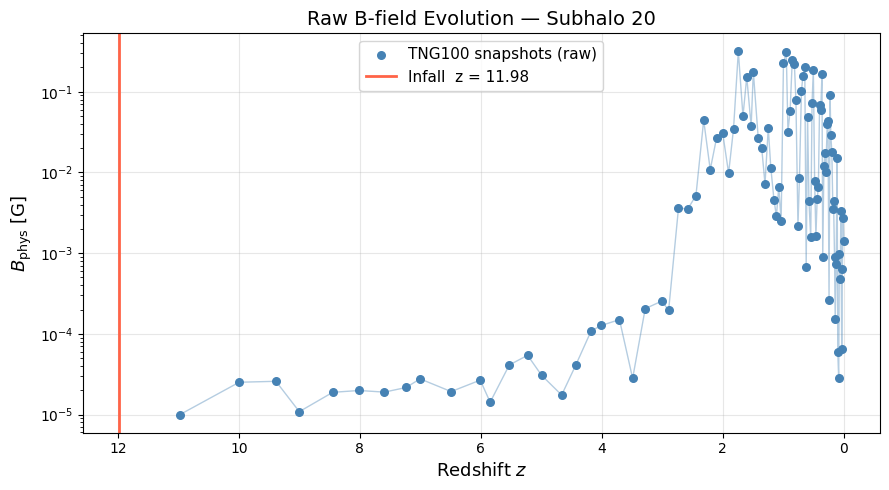

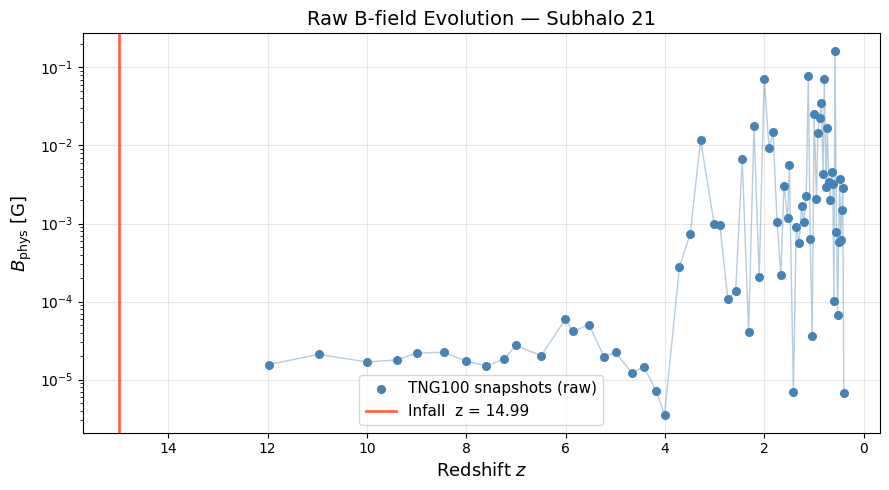

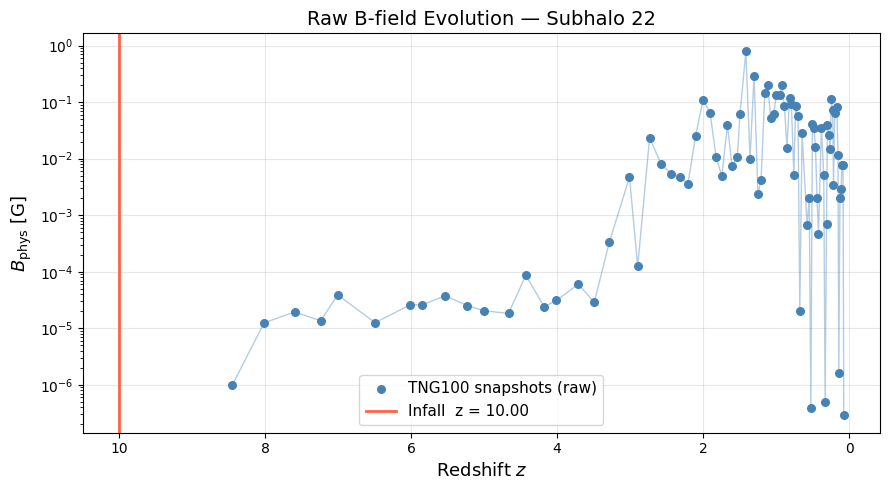

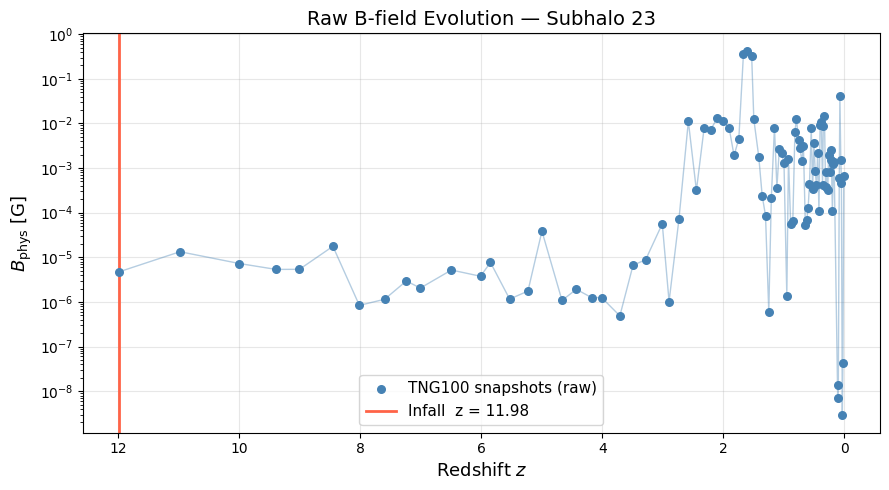

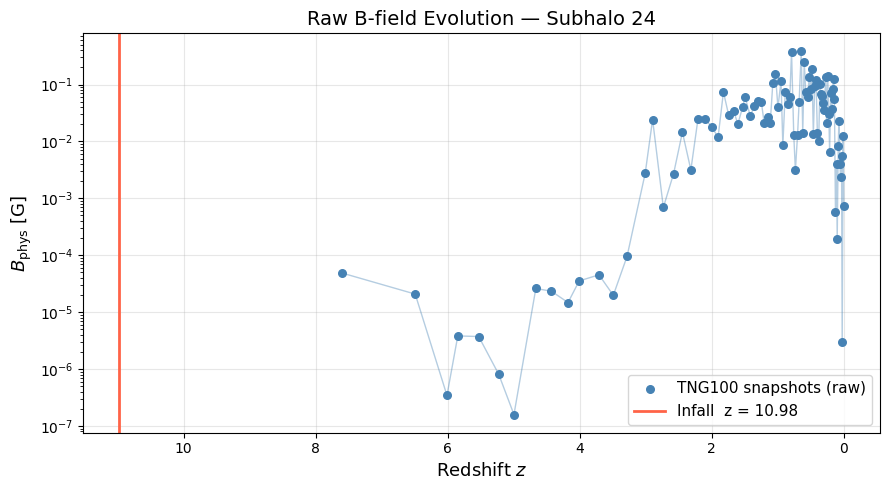

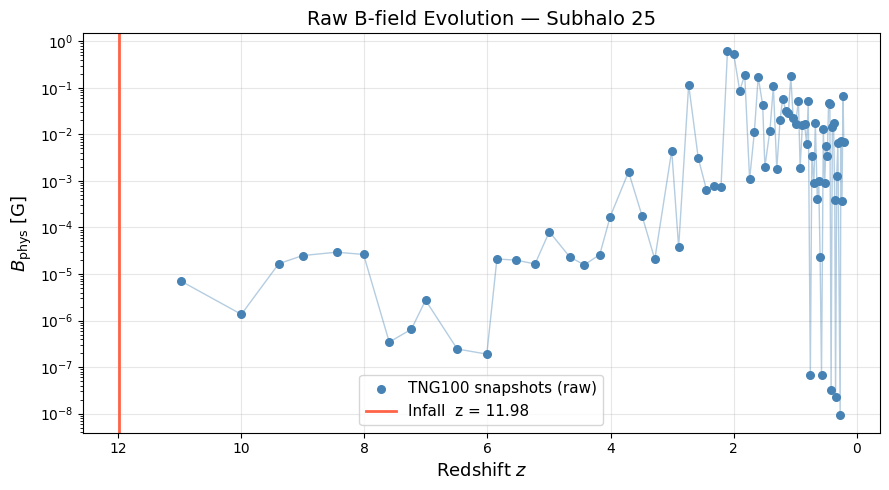

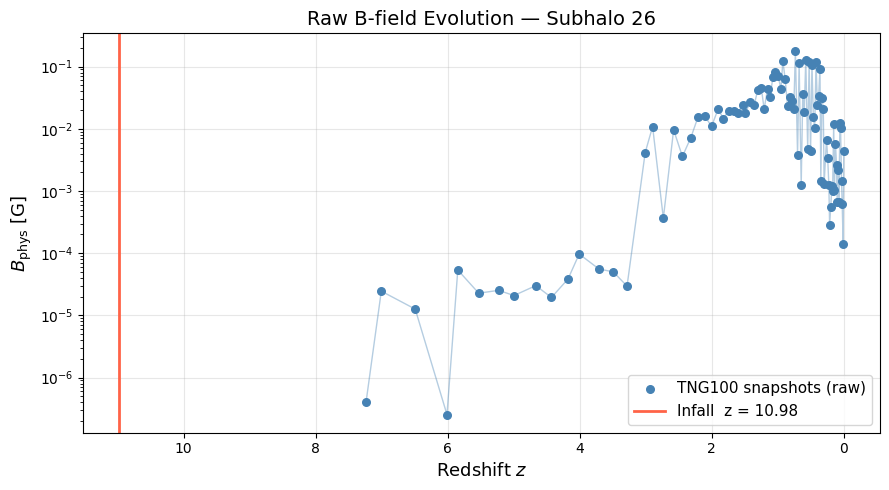

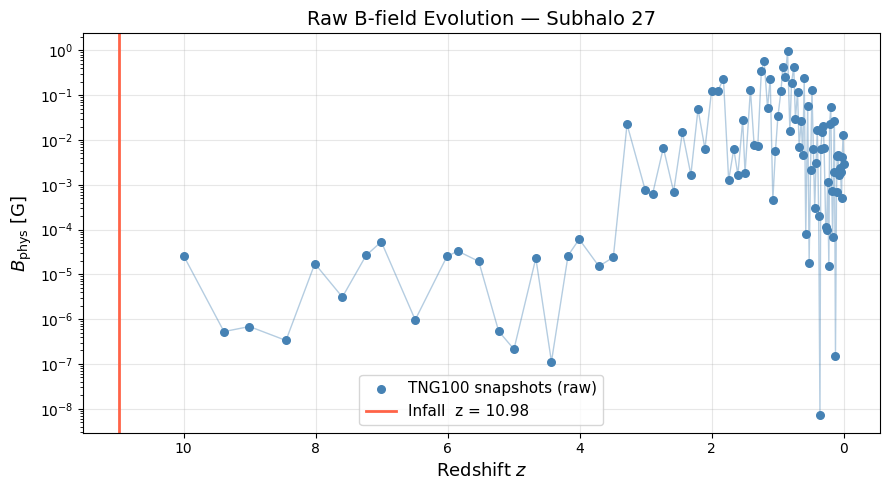

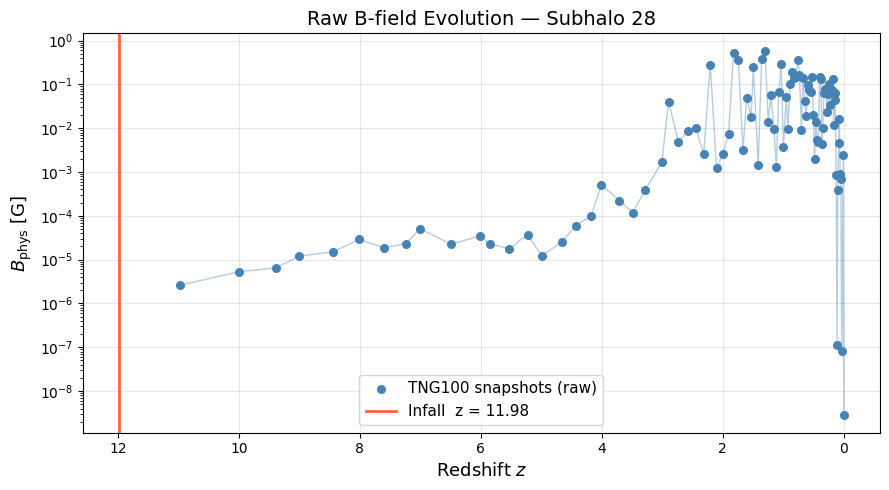

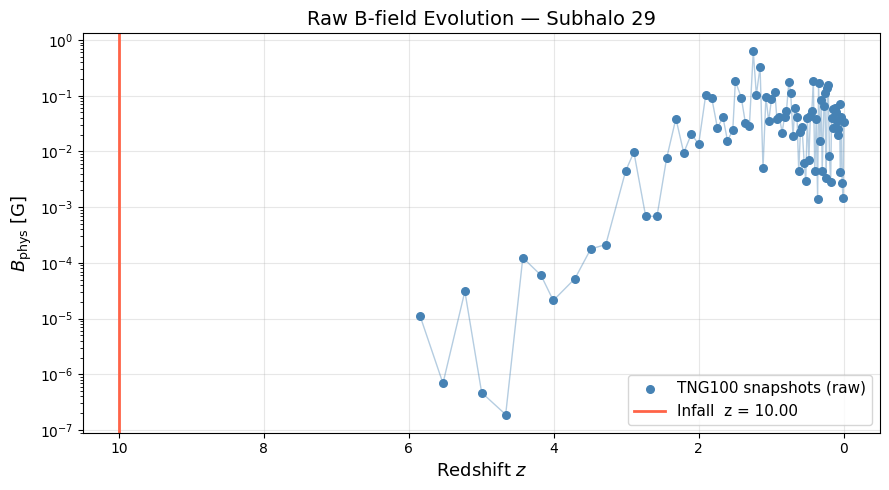

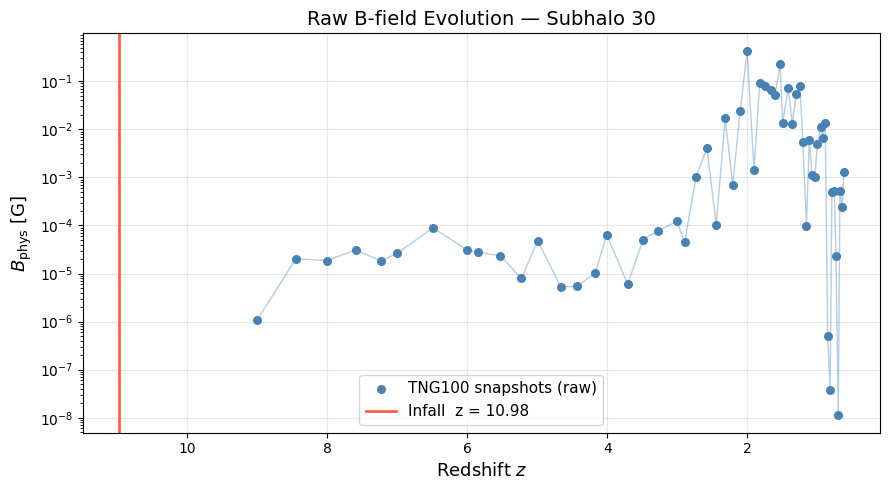

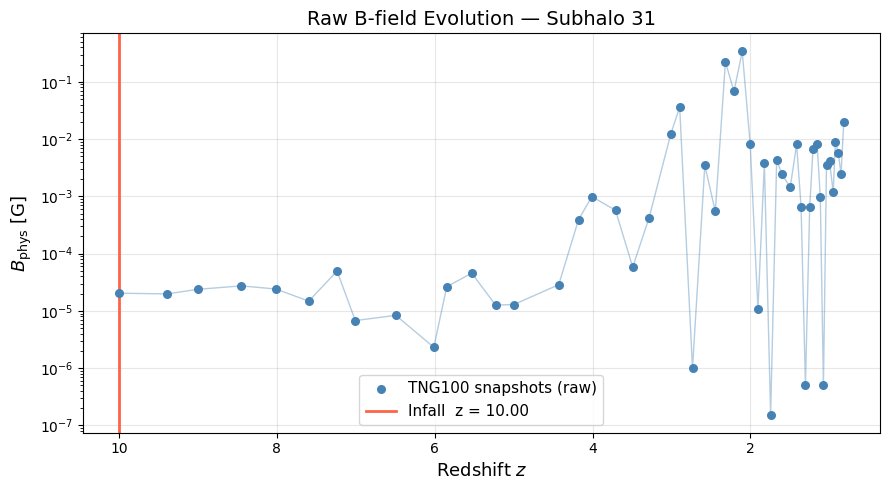

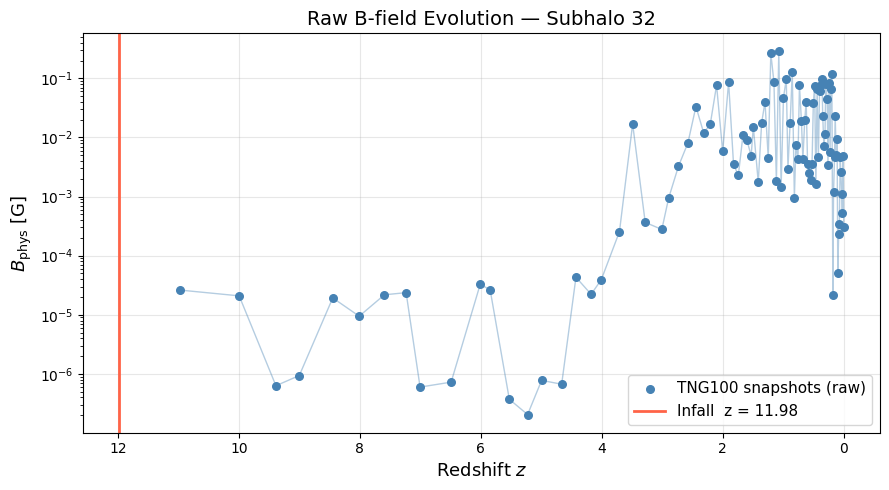

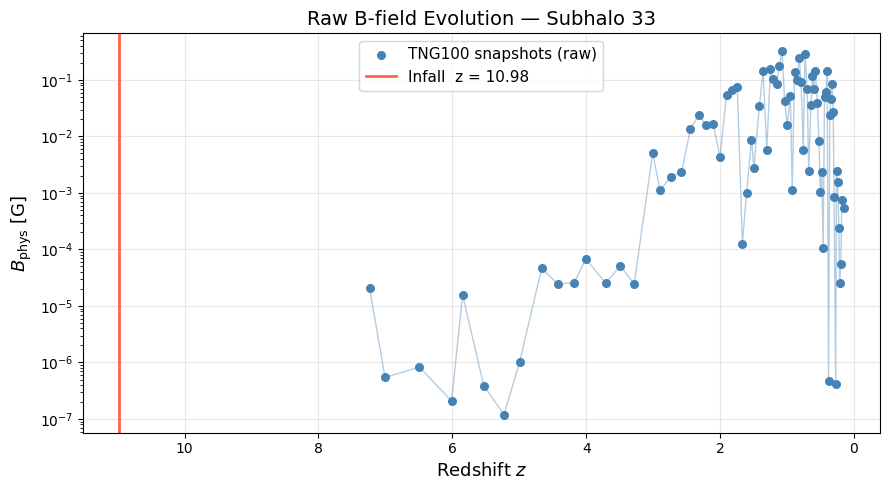

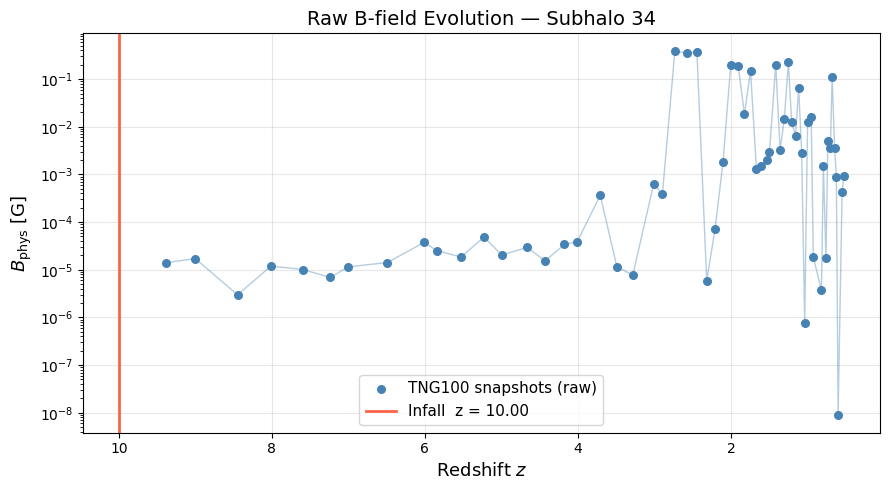

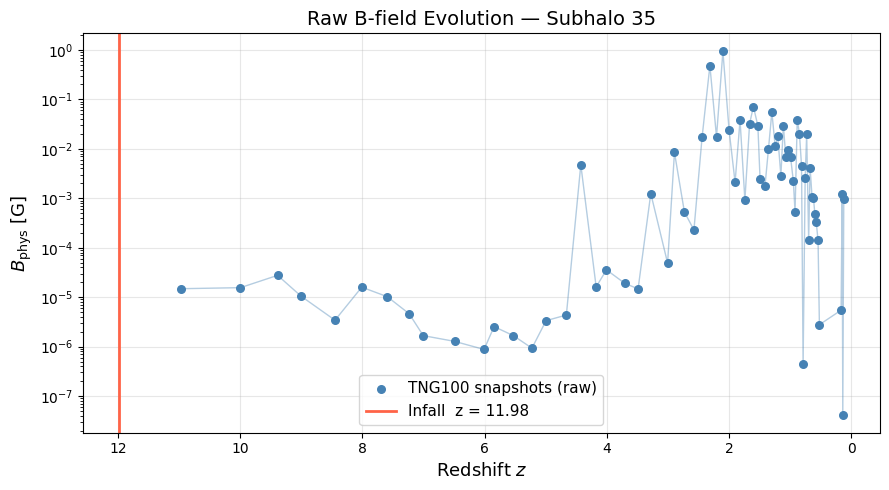

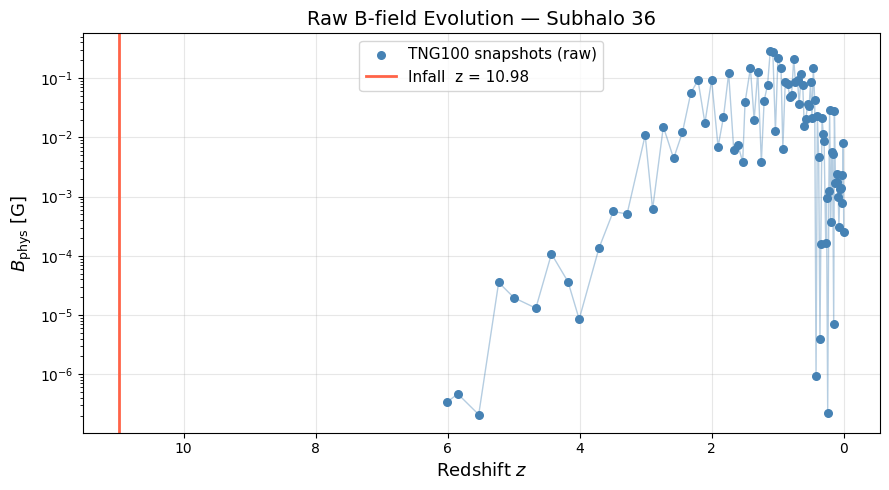

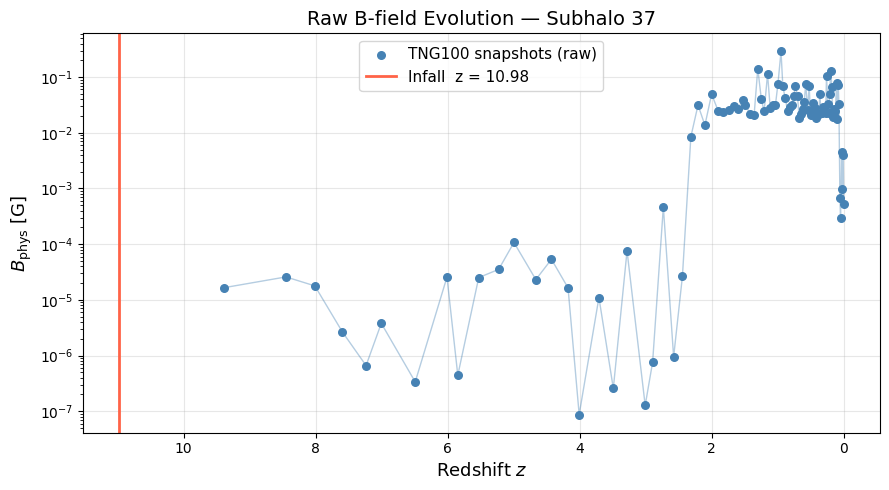

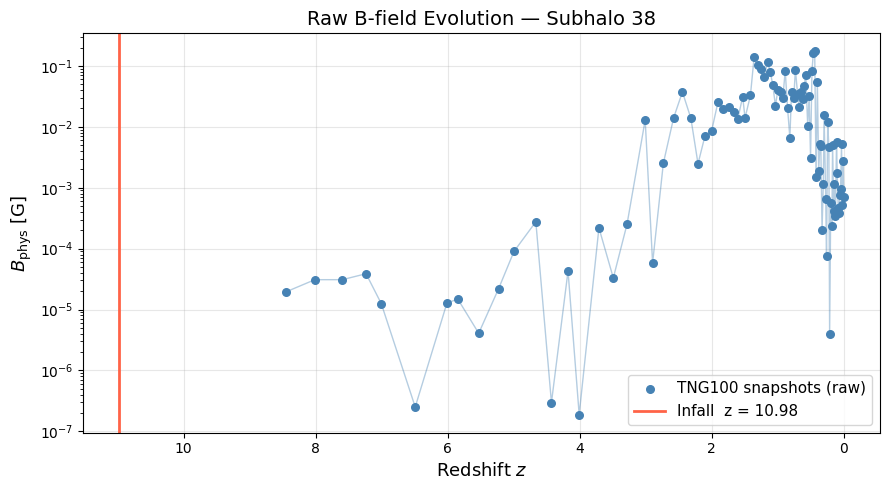

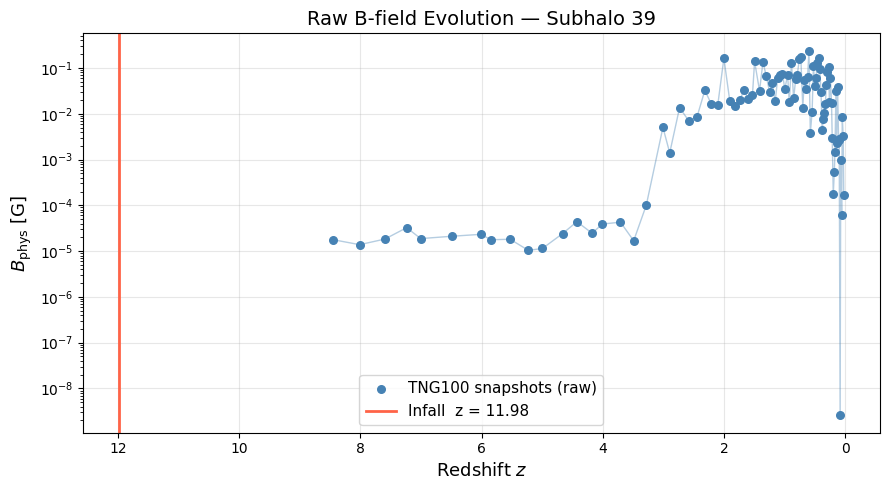

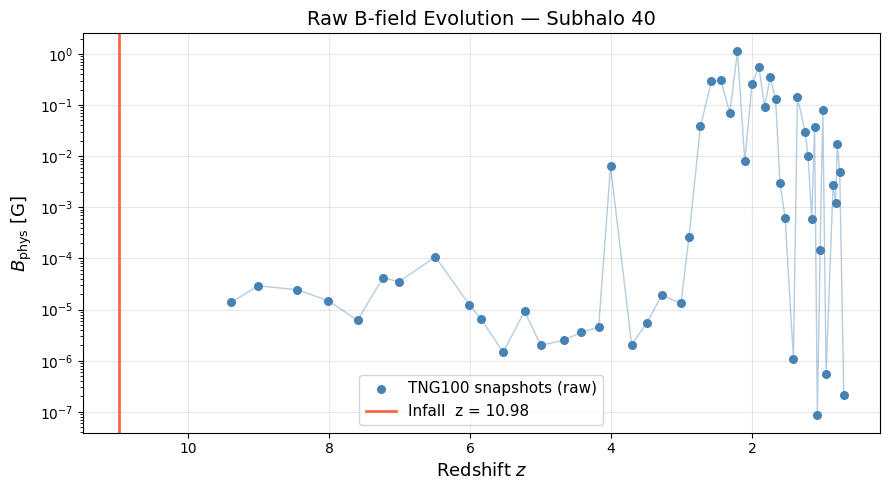

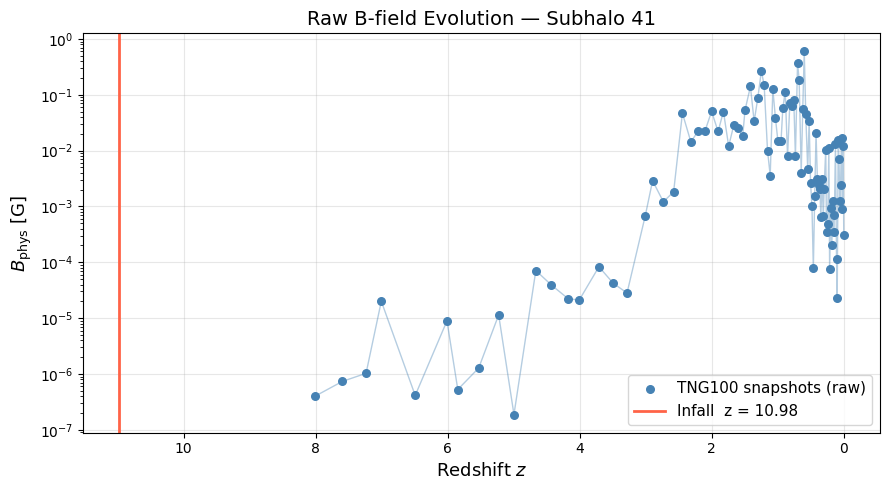

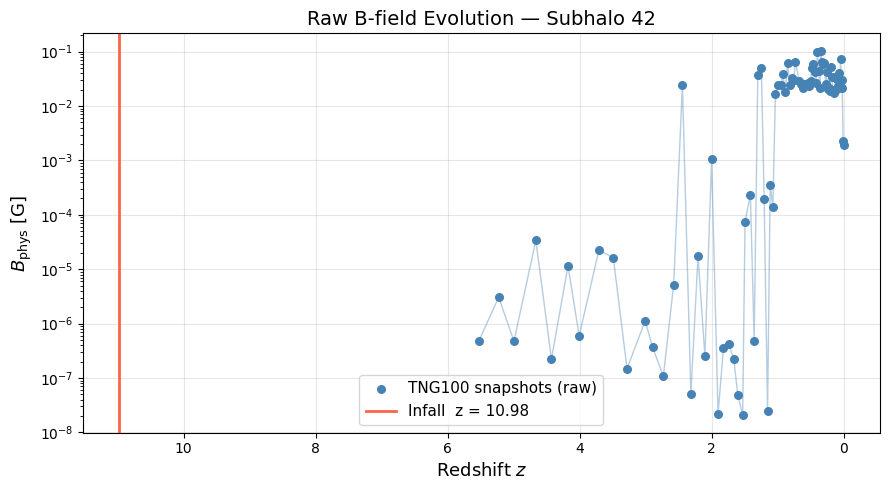

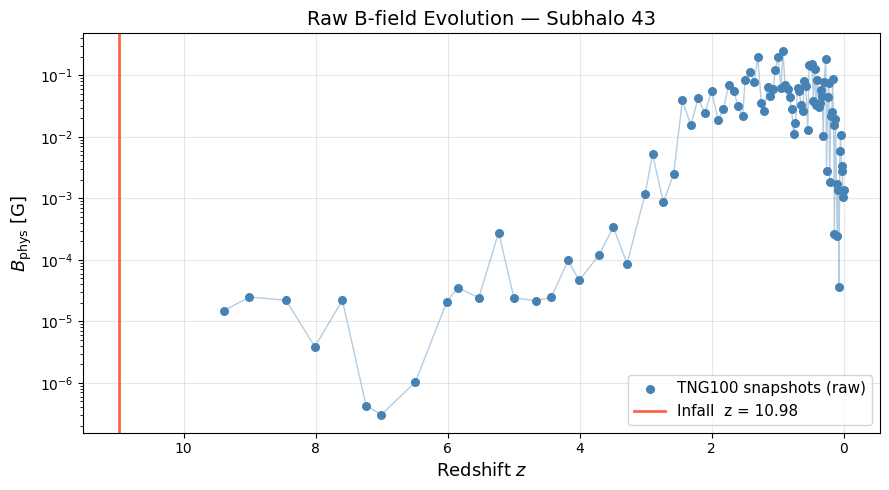

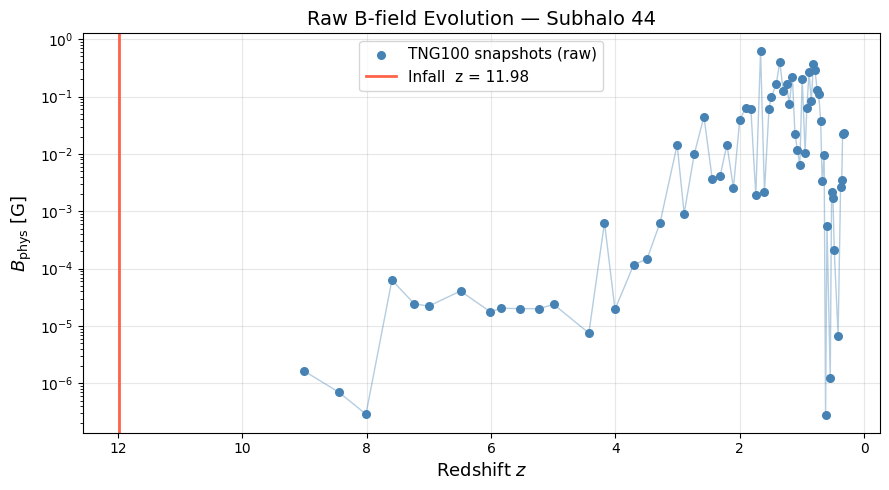

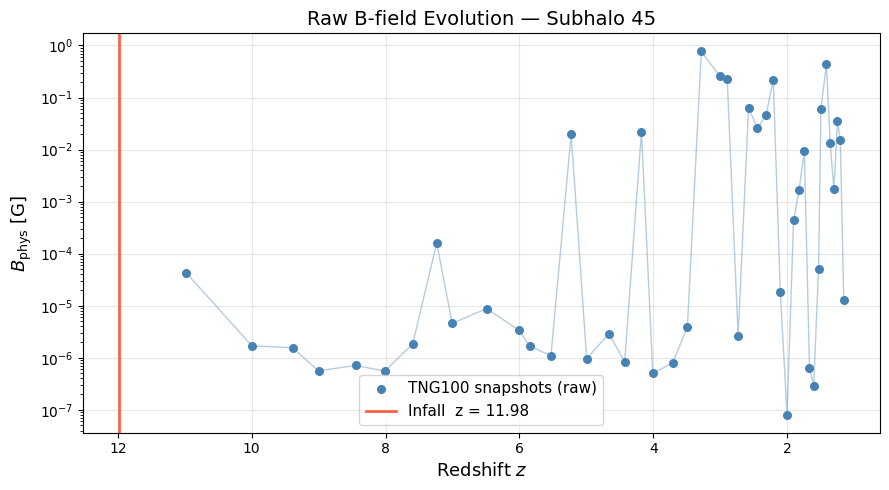

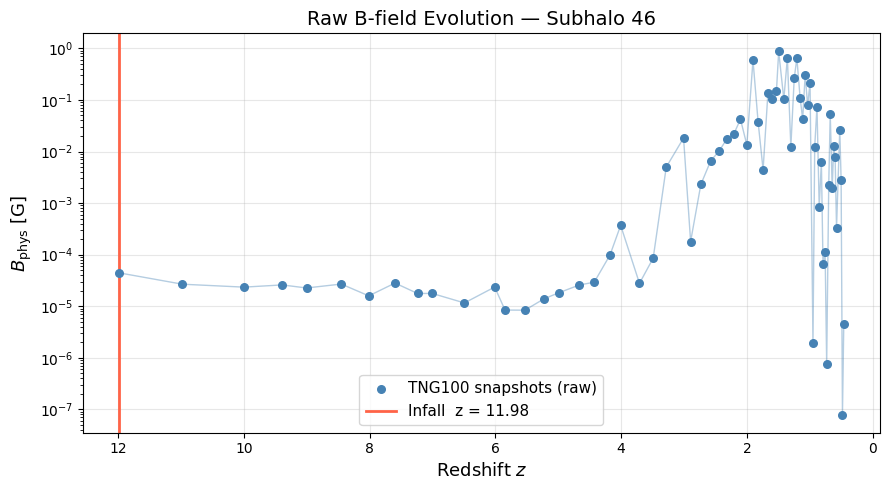

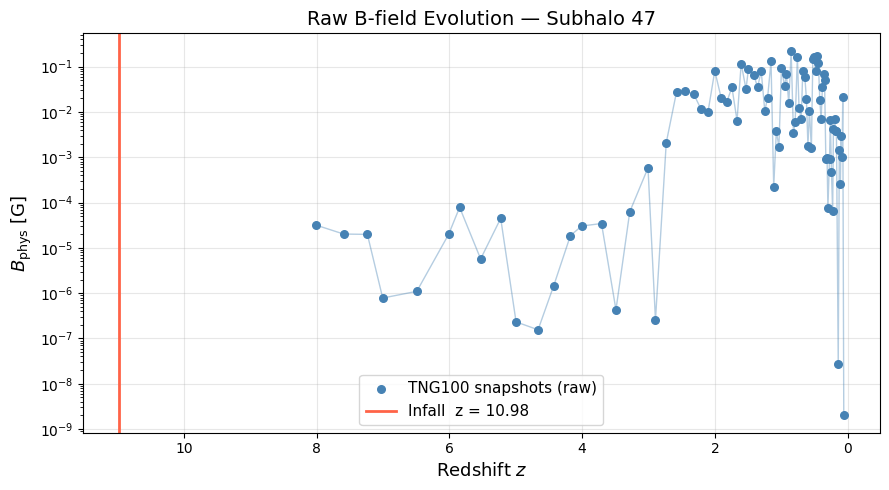

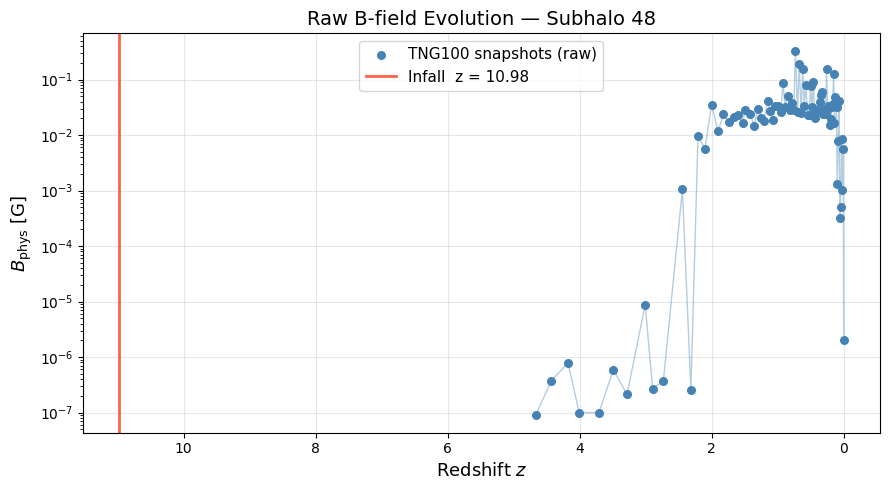

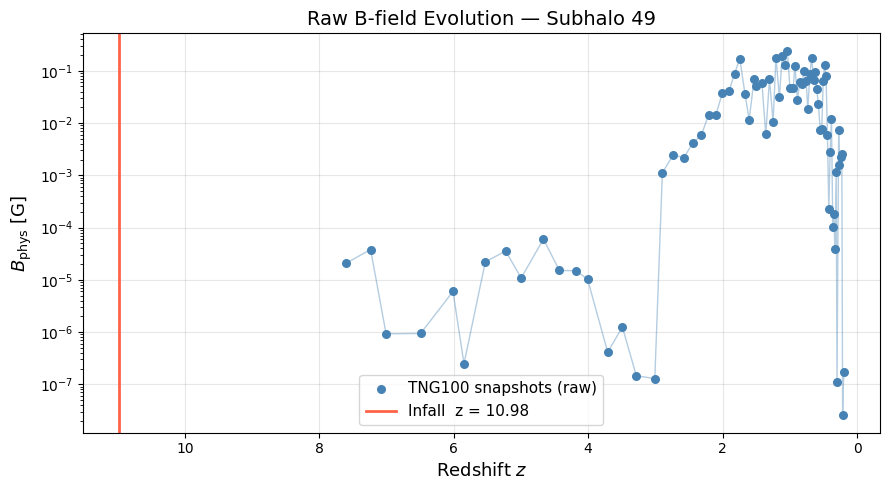

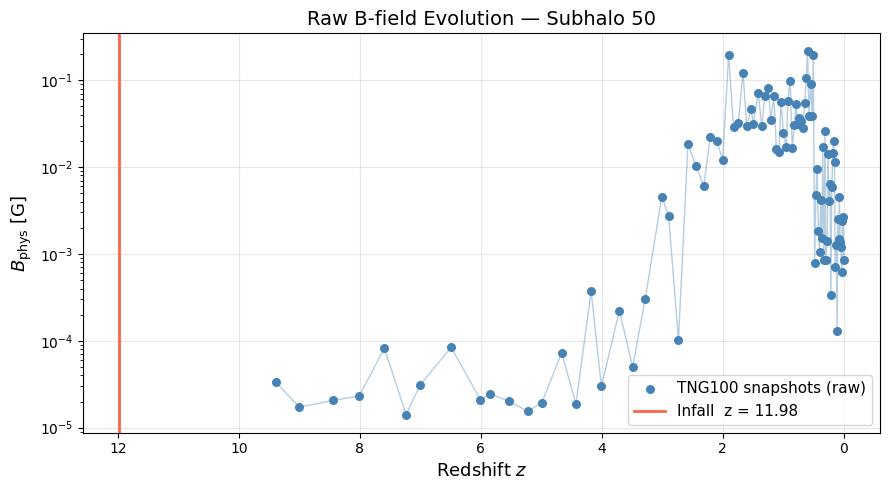

NameError: name 'subhalo_id' is not defined

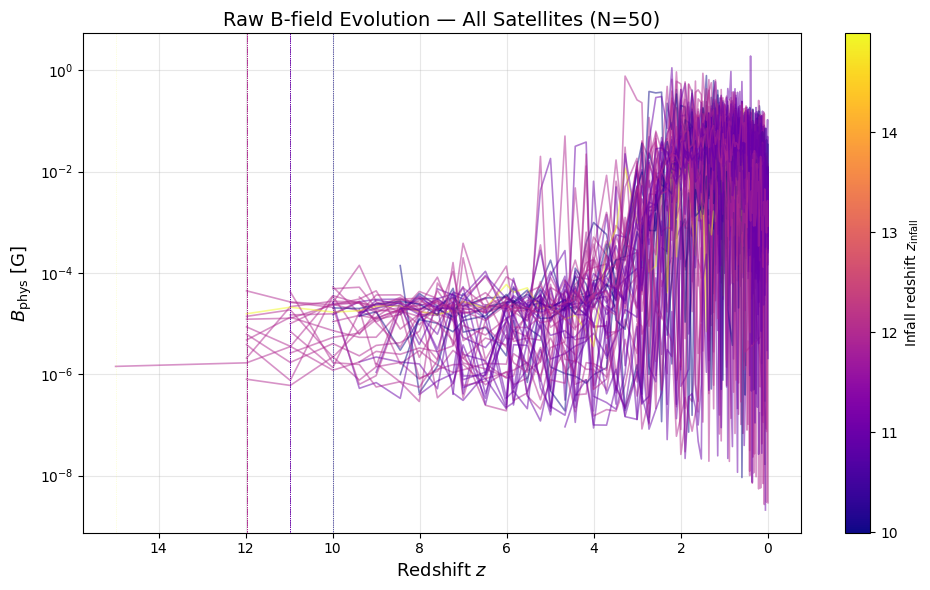

In [8]:
# Plot raw B-field vs redshift for ALL galaxies
for gal in all_galaxies:
    plot_B_vs_redshift_single(
        gal['mpb'],
        infall_info=gal['infall'],
        subhalo_id=gal['subhalo_id']
    )

# Also plot all galaxies overlaid on one figure
plot_B_vs_redshift_all(all_galaxies)

---
## 8. Kernel Smoothing + LOOCV Bandwidth Selection

The raw B-field time series is noisy and the TNG snapshots are **not uniformly spaced** in lookback time, so a standard moving average is inappropriate. We instead use a **Gaussian kernel smoother** (Nadaraya-Watson estimator) applied in lookback time:

$$\hat{B}(t) = \frac{\sum_i K_h(t - t_i)\, B_i}{\sum_i K_h(t - t_i)}, \qquad K_h(u) = \exp\!\left(-\frac{u^2}{2h^2}\right)$$

The bandwidth $h$ (in Gyr) controls the smoothing scale. We select the optimal $h^*$ using **leave-one-out cross-validation (LOOCV)**:

$$\text{CV}(h) = \frac{1}{n}\sum_{j=1}^{n}\left(B_j - \hat{B}_{(-j)}(t_j)\right)^2, \qquad h^* = \arg\min_h\,\text{CV}(h)$$

where $\hat{B}_{(-j)}$ is the smoother fit with the $j$-th point left out.

In [ ]:
# ── Kernel smoothing functions ────────────────────────────────────────────────

def gaussian_kernel(u, h):
    """Gaussian kernel: exp(-u^2 / 2h^2)"""
    return np.exp(-0.5 * (u / h)**2)


def kernel_smooth(t_query, t_obs, B_obs, h, exclude_idx=None):
    """
    Nadaraya-Watson kernel smoother with Gaussian kernel.

    Parameters
    ----------
    t_query    : float or array, query time(s) in Gyr
    t_obs      : array, observed lookback times (Gyr)
    B_obs      : array, observed B-field values
    h          : float, bandwidth in Gyr
    exclude_idx: int or None, index to exclude (used for LOOCV)

    Returns
    -------
    B_hat : smoothed estimate at t_query
    """
    mask = np.ones(len(t_obs), dtype=bool)
    if exclude_idx is not None:
        mask[exclude_idx] = False
    t_use = t_obs[mask]
    B_use = B_obs[mask]

    t_query  = np.atleast_1d(np.asarray(t_query, dtype=float))
    B_hat    = np.zeros(len(t_query))
    for k, tq in enumerate(t_query):
        weights  = gaussian_kernel(tq - t_use, h)
        w_sum    = weights.sum()
        B_hat[k] = (weights @ B_use) / w_sum if w_sum > 1e-30 else np.nan

    return B_hat if len(B_hat) > 1 else float(B_hat[0])


def loocv_score(h, t_obs, B_obs):
    """
    Leave-one-out cross-validation MSE for bandwidth h.
    For each point j, fits on all OTHER points, predicts at t_j.
    Returns mean squared prediction error.
    """
    n      = len(t_obs)
    errors = np.zeros(n)
    for j in range(n):
        B_pred    = kernel_smooth(t_obs[j], t_obs, B_obs, h, exclude_idx=j)
        errors[j] = (B_obs[j] - B_pred)**2
    return errors.mean()


def select_bandwidth(t_obs, B_obs, h_grid=None):
    """
    Select optimal bandwidth via LOOCV over a grid of h values.
    Returns h_opt, h_grid, cv_scores.
    """
    if h_grid is None:
        h_grid = np.linspace(0.1, 3.0, 50)
    cv_scores = np.array([loocv_score(h, t_obs, B_obs) for h in h_grid])
    h_opt     = h_grid[np.argmin(cv_scores)]
    return h_opt, h_grid, cv_scores


def smooth_galaxy(mpb_records, infall_info, field='B_disk_phys', h_grid=None):
    """
    Run kernel smoothing + LOOCV for one galaxy.
    All operations are performed in lookback time (Gyr).
    dt = t_infall - t_lb  (positive = after infall).
    Returns a result dict, or None if insufficient data.
    """
    valid = [r for r in mpb_records
             if np.isfinite(r.get(field, np.nan)) and r[field] > 0
             and np.isfinite(r['lookback_time'])]
    if len(valid) < 5:
        return None

    t_obs = np.array([r['lookback_time'] for r in valid])
    #B_obs = np.array([r[field]           for r in valid])
    B_obs = np.log10(np.array([r[field] for r in valid]))
    order = np.argsort(t_obs)
    t_obs, B_obs = t_obs[order], B_obs[order]

    h_opt, h_grid_out, cv_scores = select_bandwidth(t_obs, B_obs, h_grid)

    t_fine   = np.linspace(t_obs.min(), t_obs.max(), 300)
    B_smooth = kernel_smooth(t_fine, t_obs, B_obs, h_opt)

    result = {
        't_obs'     : t_obs,
        'B_obs'     : B_obs,
        'h_opt'     : h_opt,
        'h_grid'    : h_grid_out,
        'cv_scores' : cv_scores,
        't_fine'    : t_fine,
        'B_smooth'  : B_smooth,
    }

    result['B_smooth'] = 10**B_smooth
    result['B_obs']    = 10**B_obs
    if infall_info:
        t_inf               = infall_info['lookback_time']
        result['t_infall']  = t_inf
        result['dt_obs']    = t_inf - t_obs    # positive = after infall
        result['dt_fine']   = t_inf - t_fine
    return result


print('Kernel smoothing functions defined.')

Kernel smoothing functions defined.


Optimal bandwidth : h* = 0.869 Gyr


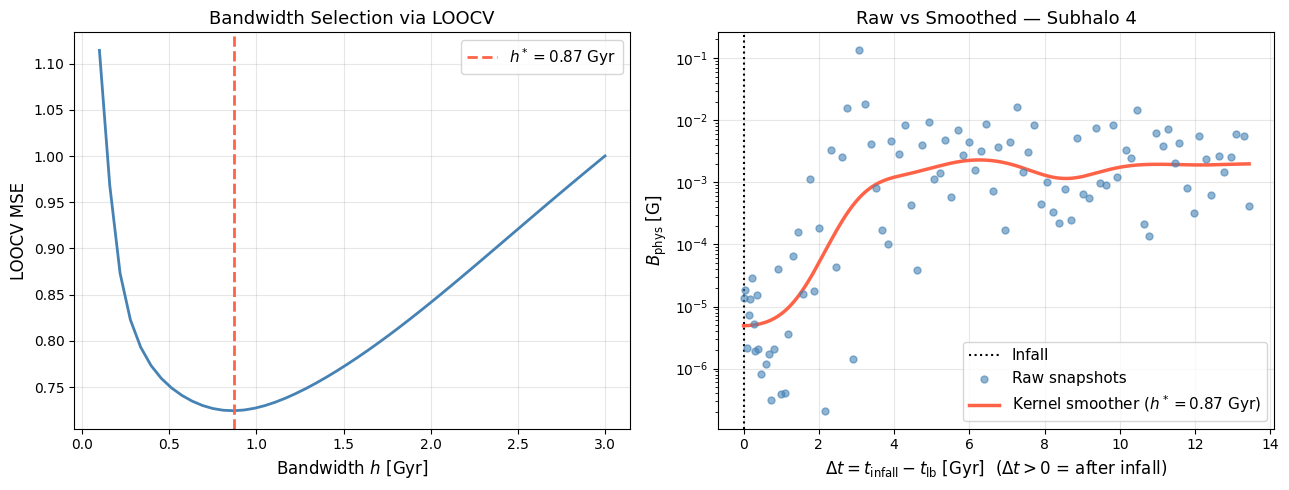

In [ ]:
def plot_smoothing_diagnostics(smooth_result, subhalo_id=None):
    """Two-panel: LOOCV curve (left) + raw vs smoothed (right)."""
    if smooth_result is None:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Left: LOOCV curve
    ax1.plot(smooth_result['h_grid'], smooth_result['cv_scores'],
             color='steelblue', lw=2)
    ax1.axvline(smooth_result['h_opt'], color='tomato', lw=2, ls='--',
                label=f"$h^* = {smooth_result['h_opt']:.2f}$ Gyr")
    ax1.set_xlabel('Bandwidth $h$ [Gyr]', fontsize=12)
    ax1.set_ylabel('LOOCV MSE', fontsize=12)
    ax1.set_title('Bandwidth Selection via LOOCV', fontsize=13)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Right: raw vs smoothed
    if 'dt_obs' in smooth_result:
        x_obs  = smooth_result['dt_obs']
        x_fine = smooth_result['dt_fine']
        xlabel = r'$\Delta t = t_{\rm infall} - t_{\rm lb}$ [Gyr]  ($\Delta t > 0$ = after infall)'
        ax2.axvline(0, color='black', lw=1.5, ls=':', label='Infall')
    else:
        x_obs  = smooth_result['t_obs']
        x_fine = smooth_result['t_fine']
        xlabel = 'Lookback time [Gyr]'

    ax2.scatter(x_obs, smooth_result['B_obs'], s=25,
                color='steelblue', alpha=0.6, zorder=3, label='Raw snapshots')
    ax2.plot(x_fine, smooth_result['B_smooth'], color='tomato', lw=2.5,
             label=f"Kernel smoother ($h^*={smooth_result['h_opt']:.2f}$ Gyr)")
    ax2.set_yscale('log')
    ax2.set_xlabel(xlabel, fontsize=12)
    ax2.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=12)
    ax2.set_title(f'Raw vs Smoothed — Subhalo {subhalo_id}', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig(f'results/figures/diagnostics_subhalo_{subhalo_id}.png', dpi=150)
    plt.savefig(repo_root / f'results/figures/B_vs_z_subhalo_{subhalo_id}.png', dpi=150)
    plt.show()


# Test smoothing on the single test galaxy first
smooth_result = smooth_galaxy(mpb_data, infall)
if smooth_result:
    print(f'Optimal bandwidth : h* = {smooth_result["h_opt"]:.3f} Gyr')
    plot_smoothing_diagnostics(smooth_result, subhalo_id=test_id)
else:
    print('Not enough valid data points for smoothing.')

[1/40] Smoothing SubhaloID 1 ... h* = 1.22 Gyr
[2/40] Smoothing SubhaloID 2 ... h* = 0.93 Gyr
[3/40] Smoothing SubhaloID 3 ... h* = 0.63 Gyr
[4/40] Smoothing SubhaloID 4 ... h* = 0.87 Gyr
[5/40] Smoothing SubhaloID 5 ... h* = 0.87 Gyr
[6/40] Smoothing SubhaloID 6 ... h* = 0.10 Gyr
[7/40] Smoothing SubhaloID 7 ... h* = 0.10 Gyr
[8/40] Smoothing SubhaloID 8 ... h* = 0.28 Gyr
[9/40] Smoothing SubhaloID 9 ... h* = 0.81 Gyr
[10/40] Smoothing SubhaloID 10 ... h* = 0.87 Gyr
[11/40] Smoothing SubhaloID 11 ... h* = 0.87 Gyr
[12/40] Smoothing SubhaloID 12 ... h* = 1.64 Gyr
[13/40] Smoothing SubhaloID 13 ... h* = 1.70 Gyr
[14/40] Smoothing SubhaloID 14 ... h* = 0.63 Gyr
[15/40] Smoothing SubhaloID 15 ... h* = 0.57 Gyr
[16/40] Smoothing SubhaloID 16 ... h* = 0.16 Gyr
[17/40] Smoothing SubhaloID 17 ... h* = 0.81 Gyr
[18/40] Smoothing SubhaloID 18 ... h* = 0.51 Gyr
[19/40] Smoothing SubhaloID 19 ... h* = 0.46 Gyr
[20/40] Smoothing SubhaloID 20 ... h* = 0.57 Gyr
[21/40] Smoothing SubhaloID 21 ... h* 

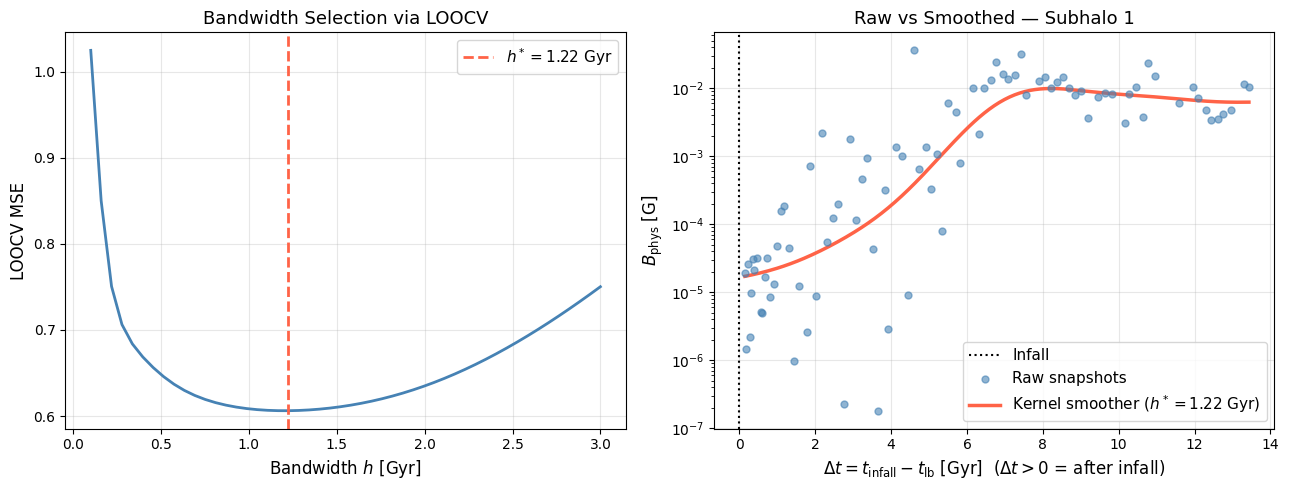

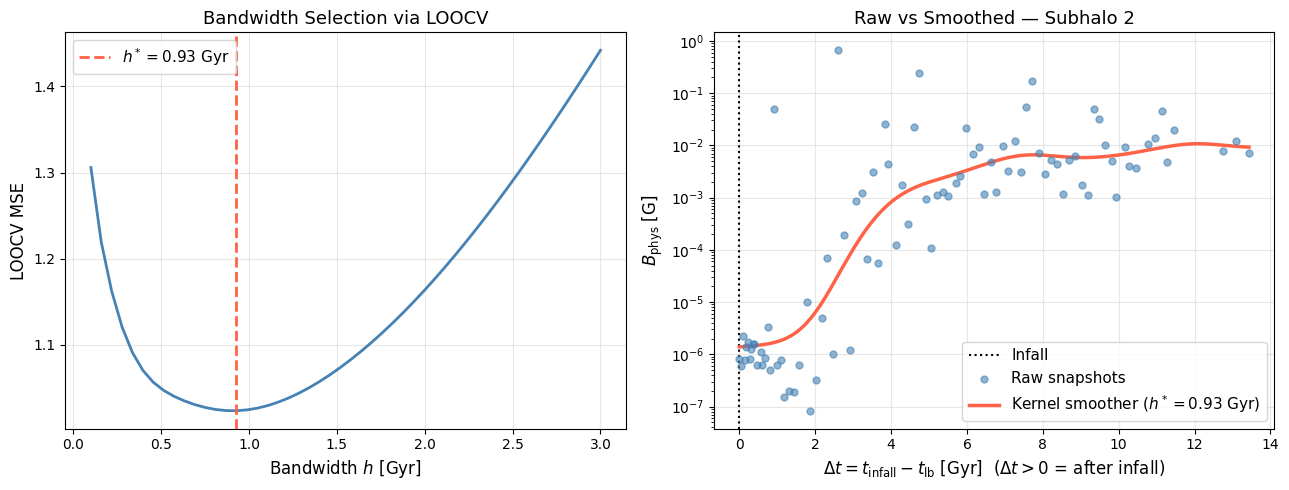

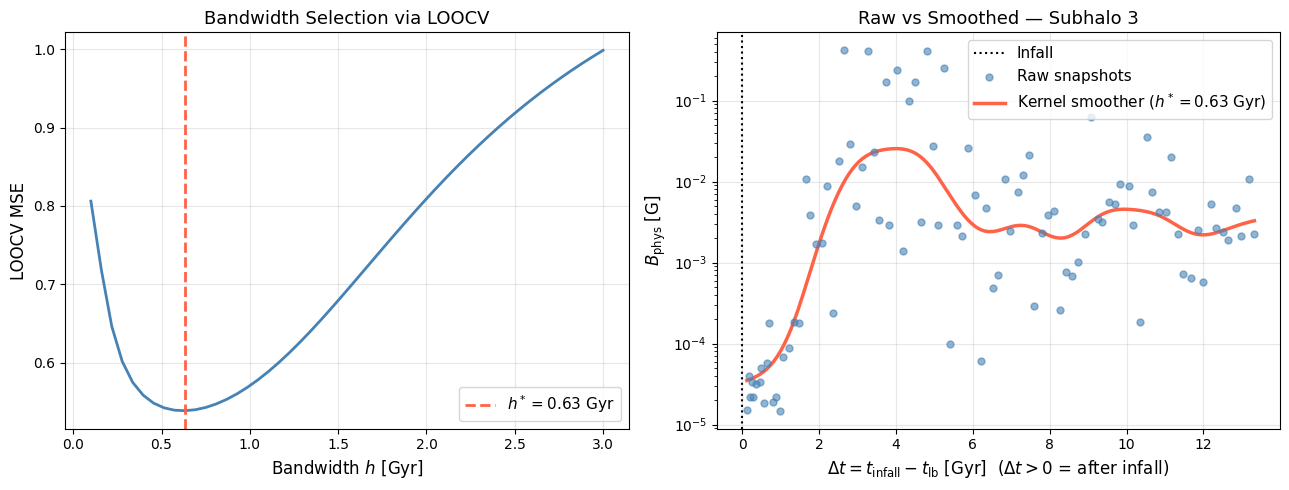

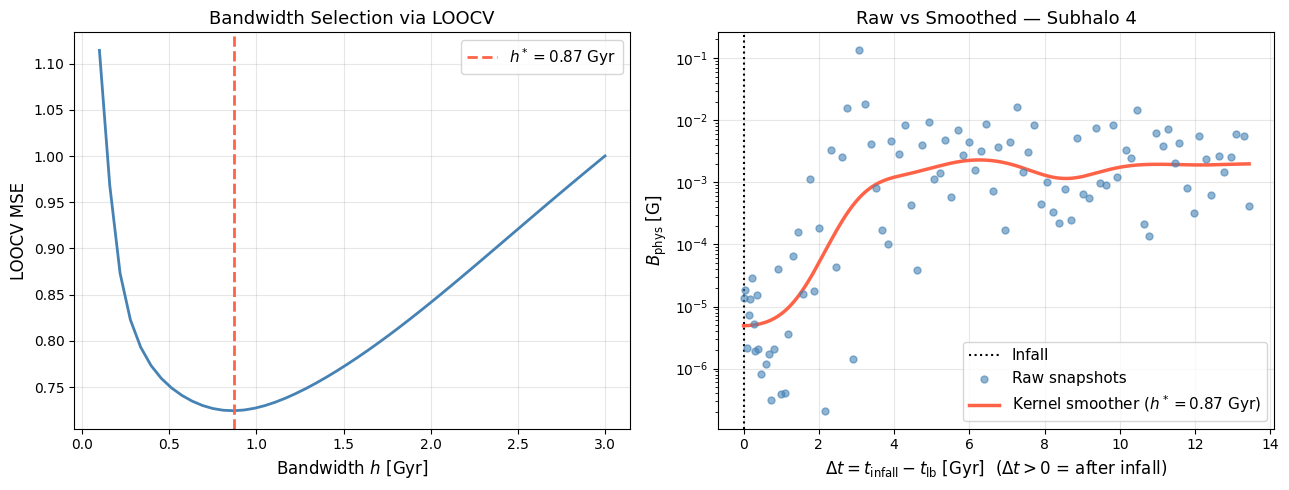

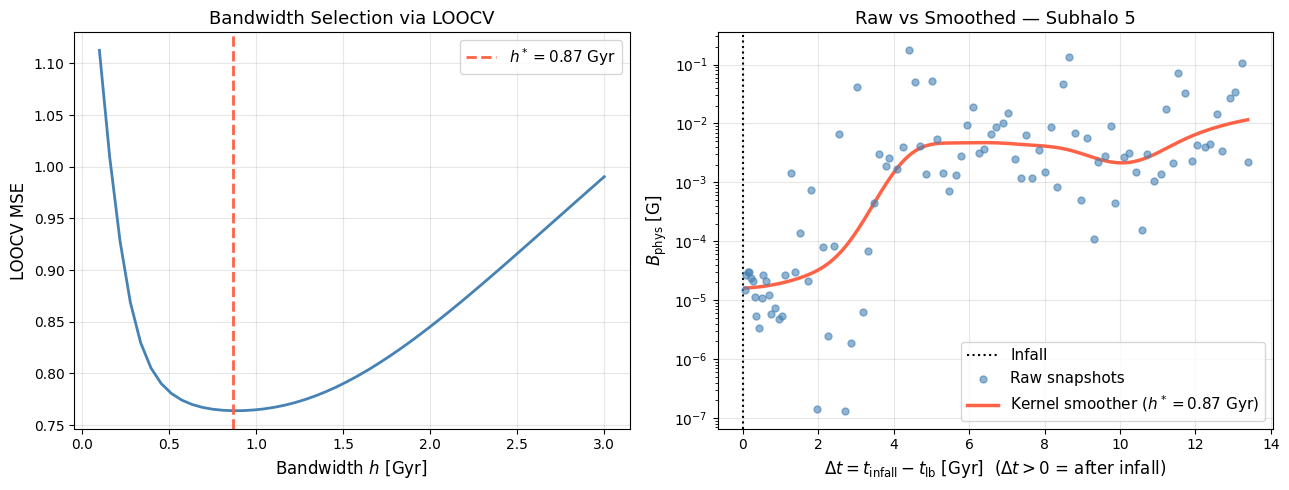

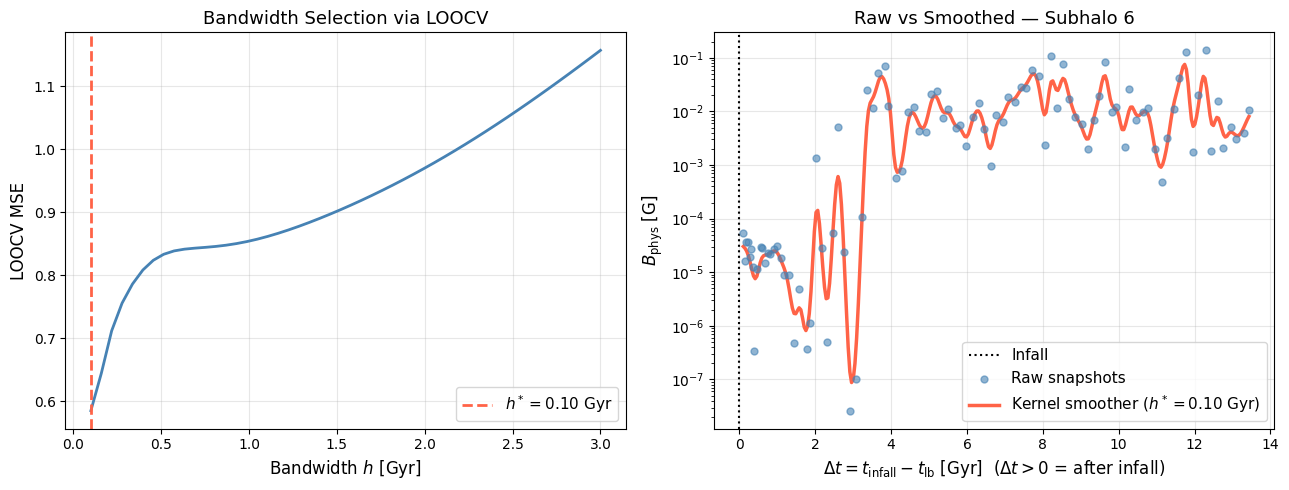

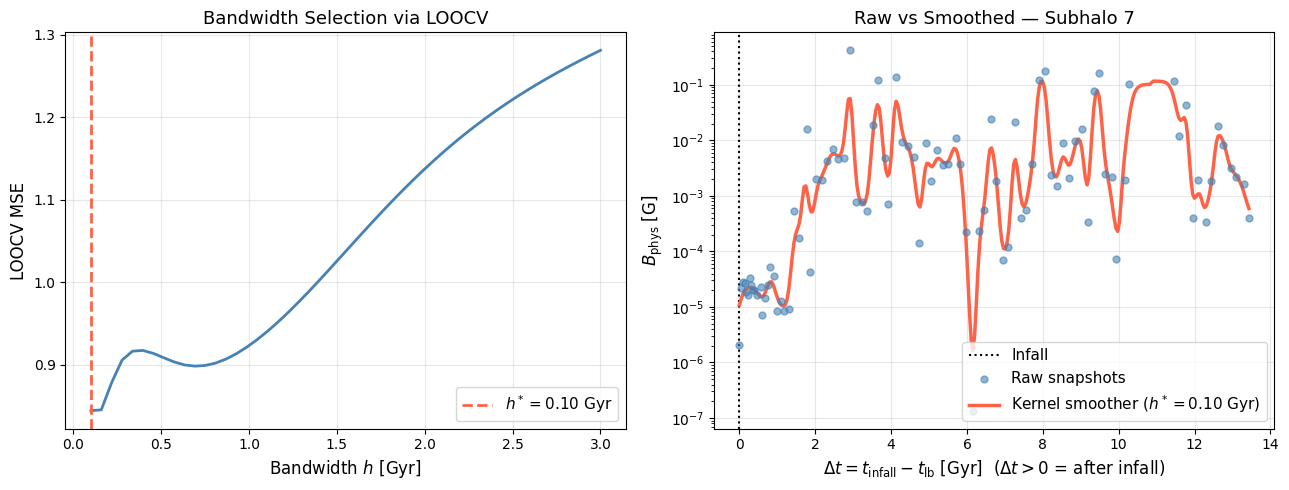

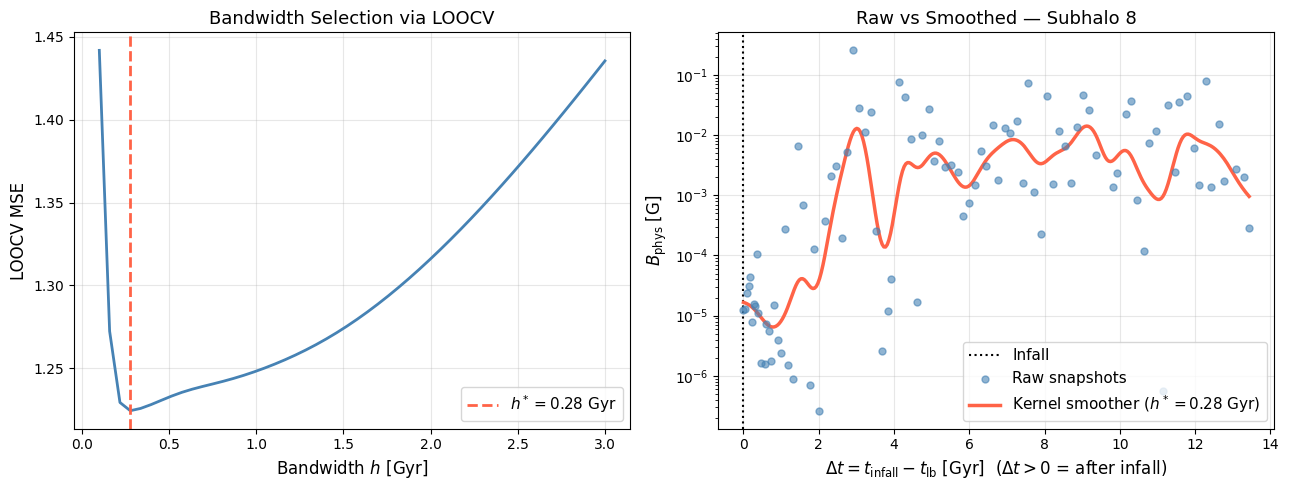

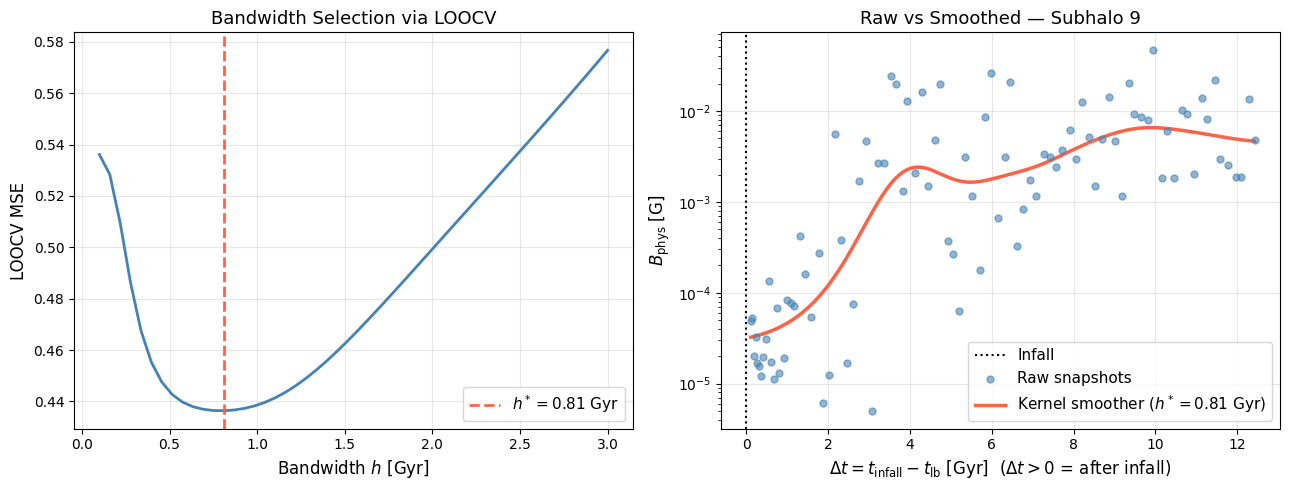

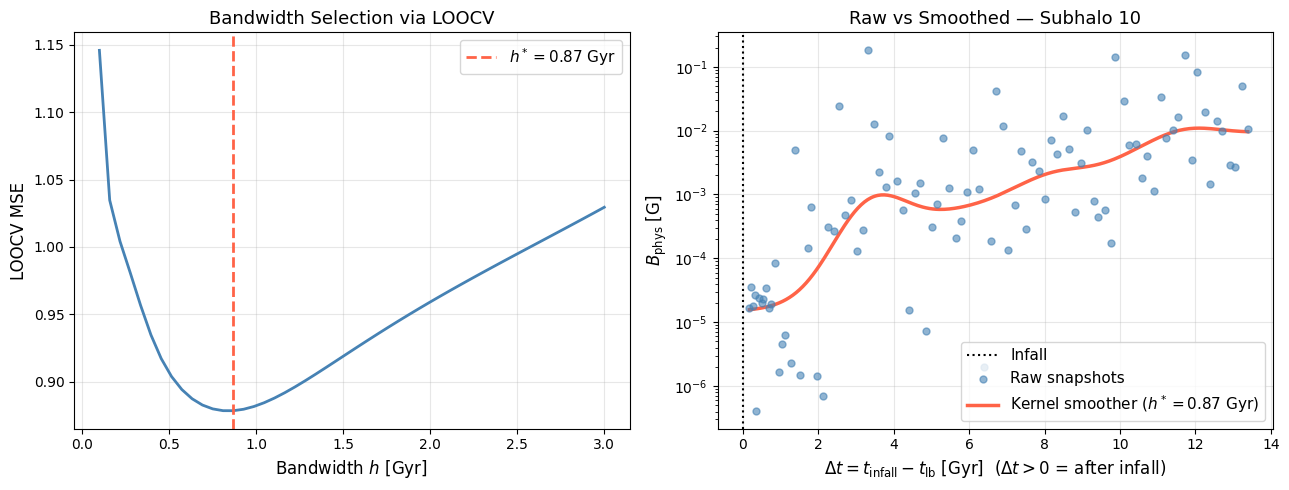

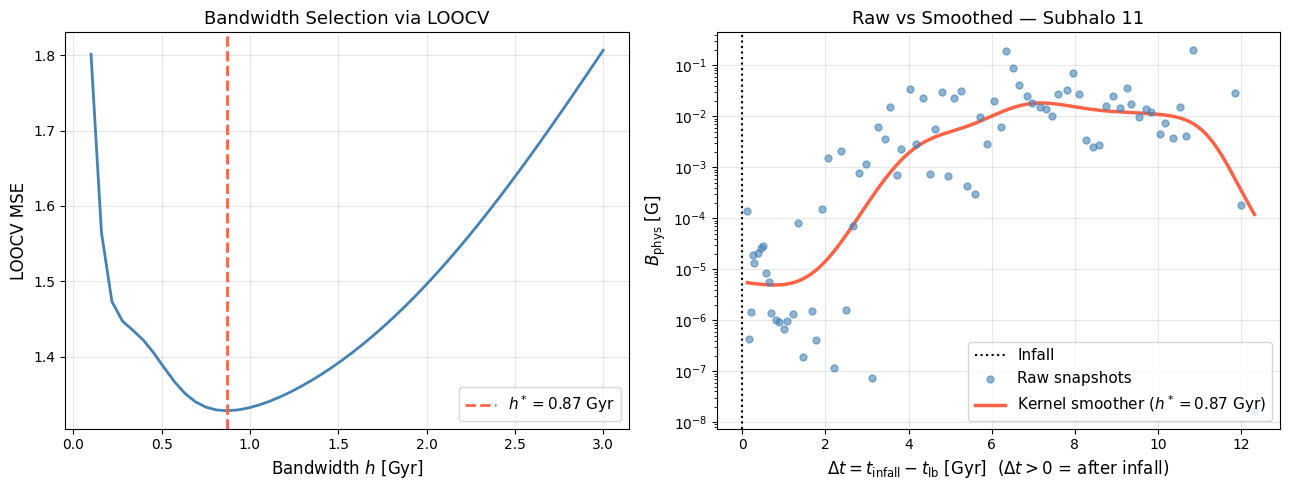

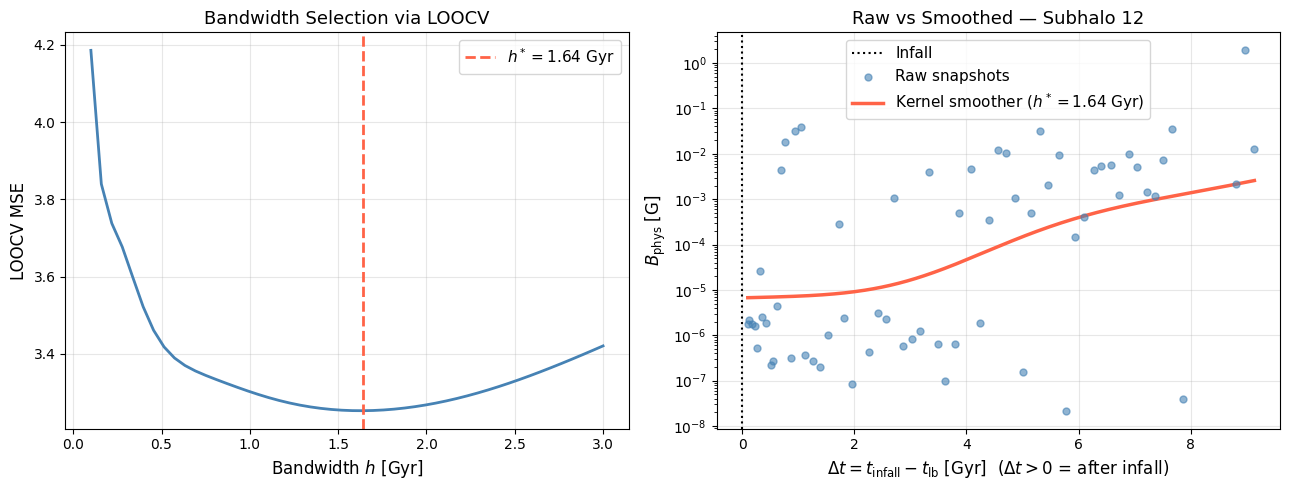

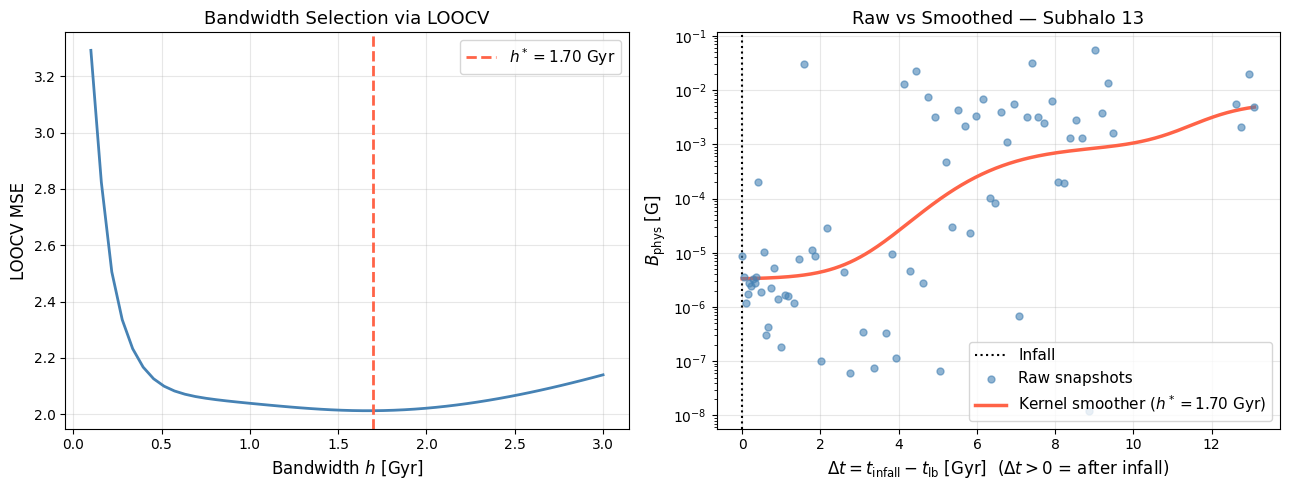

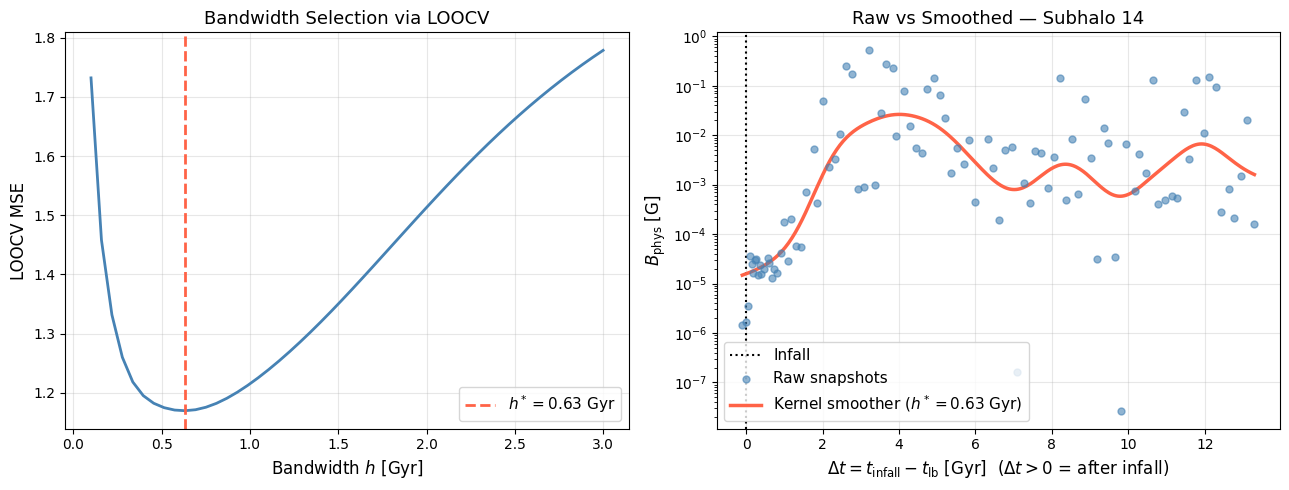

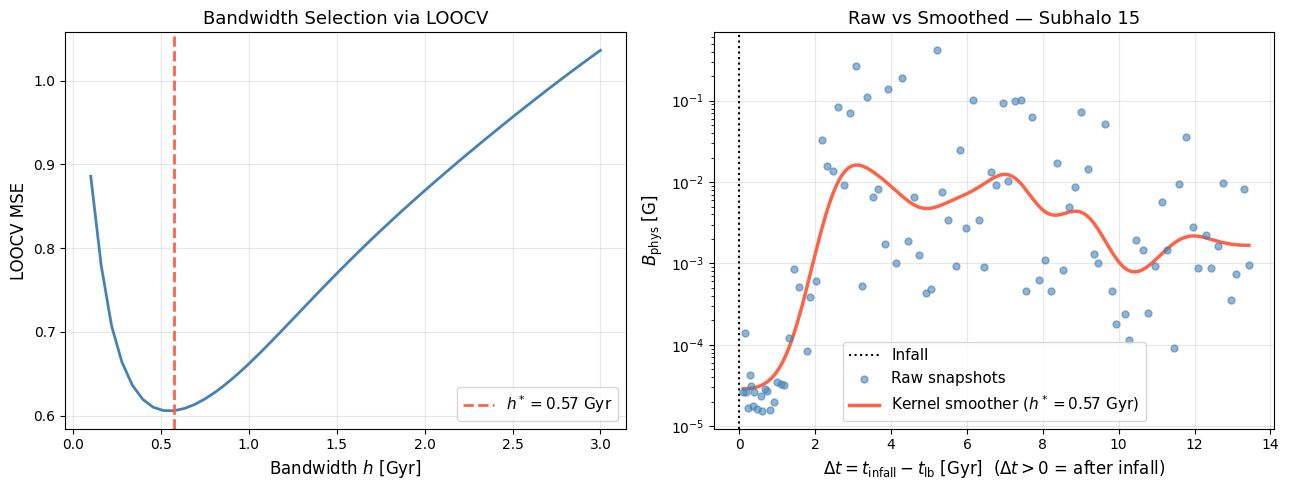

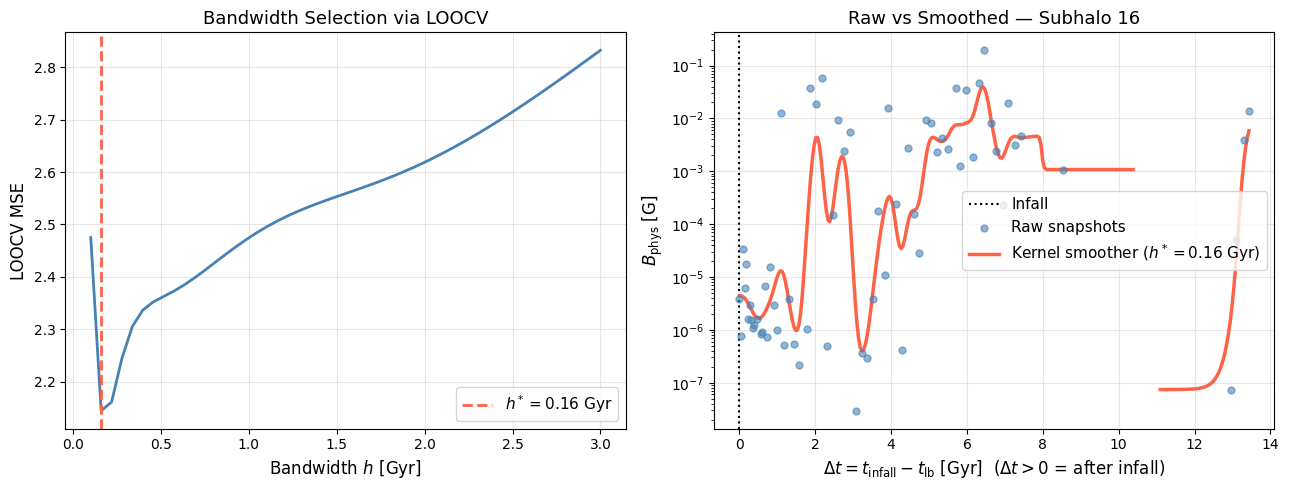

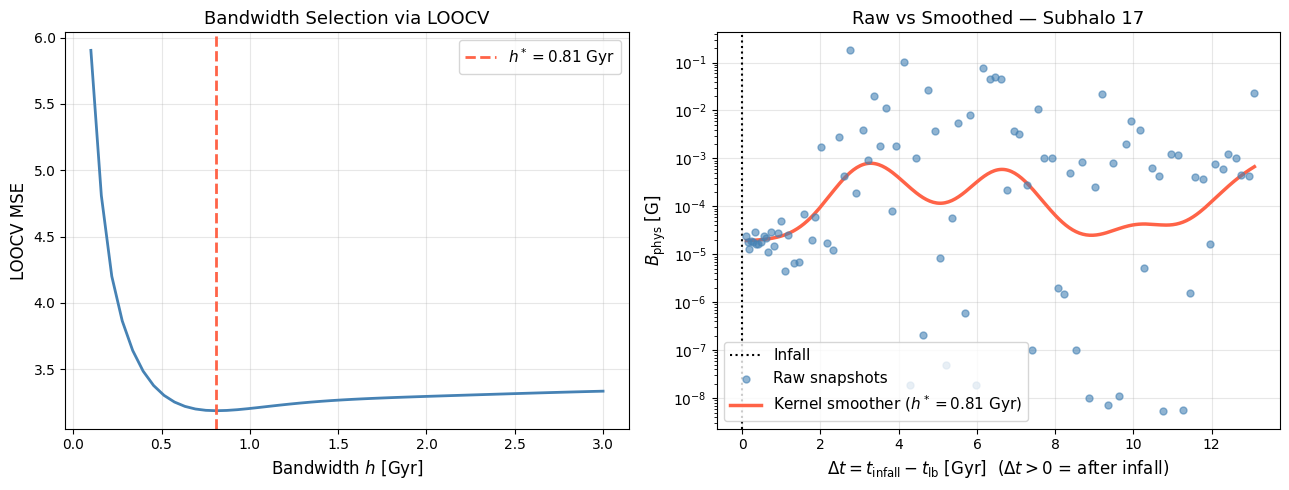

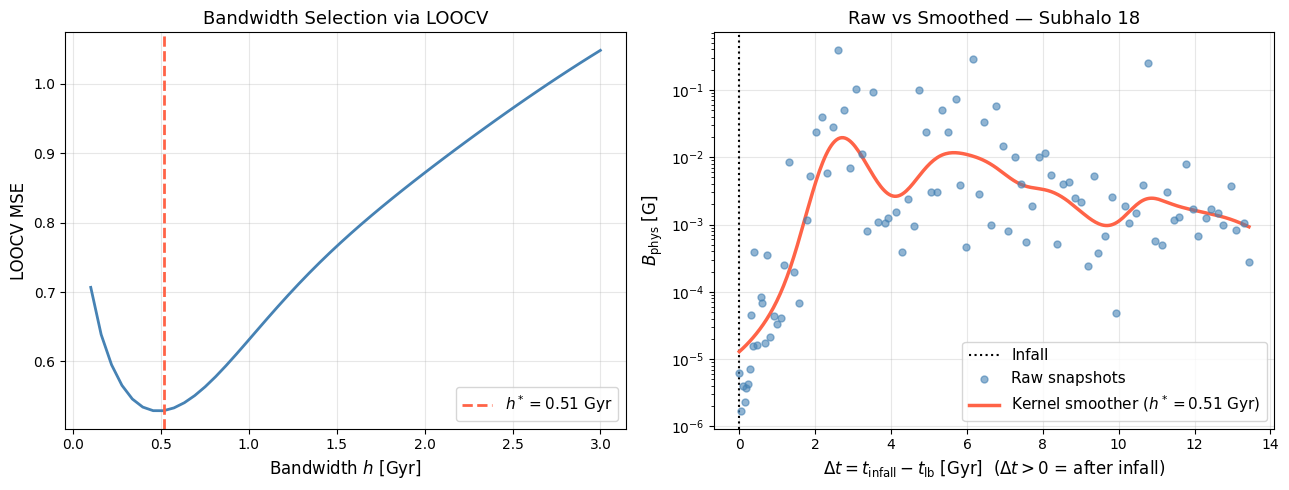

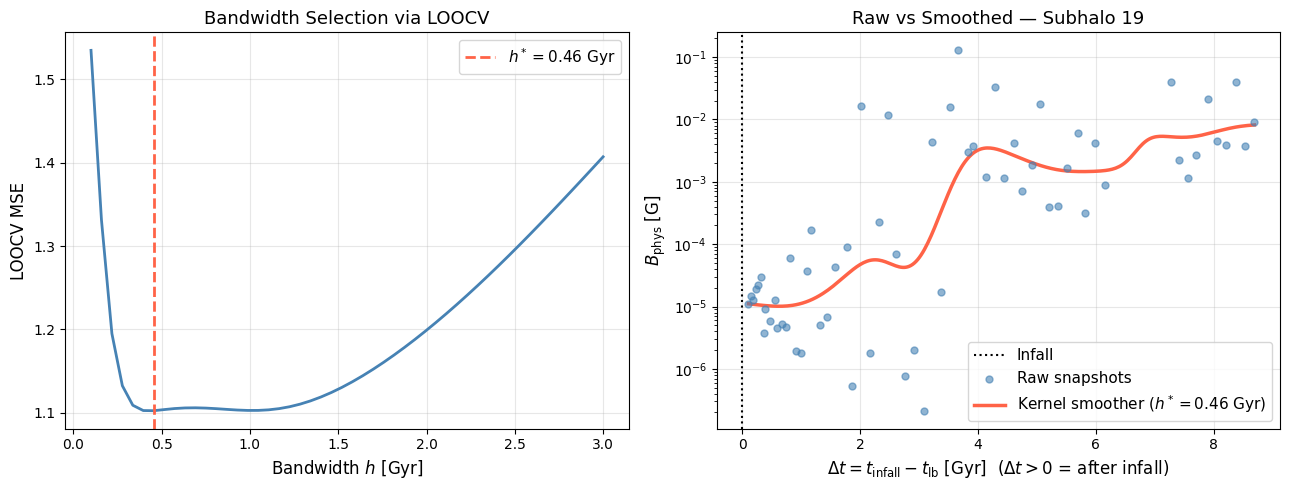

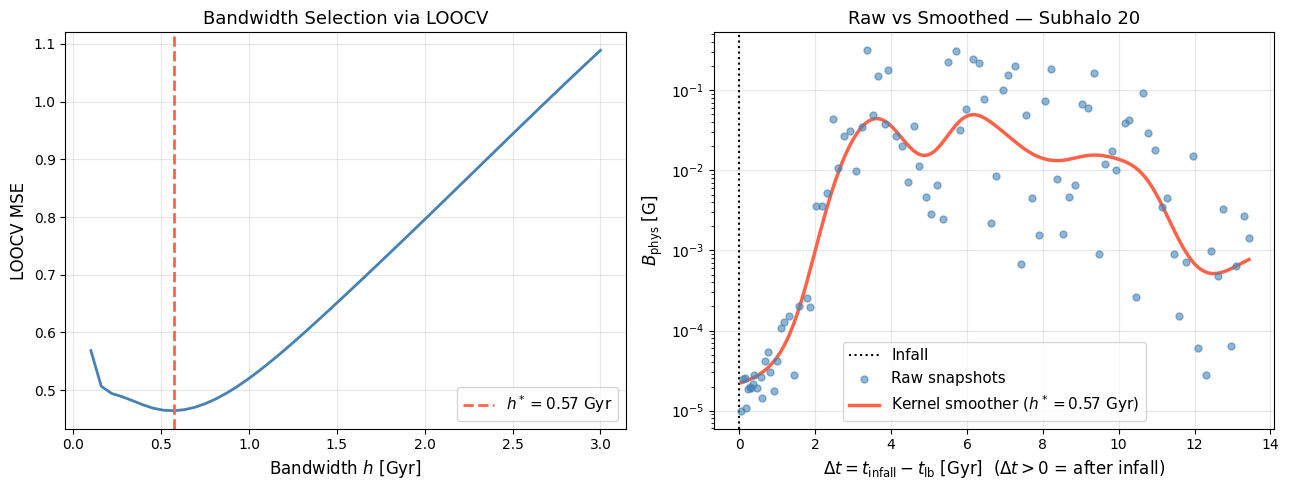

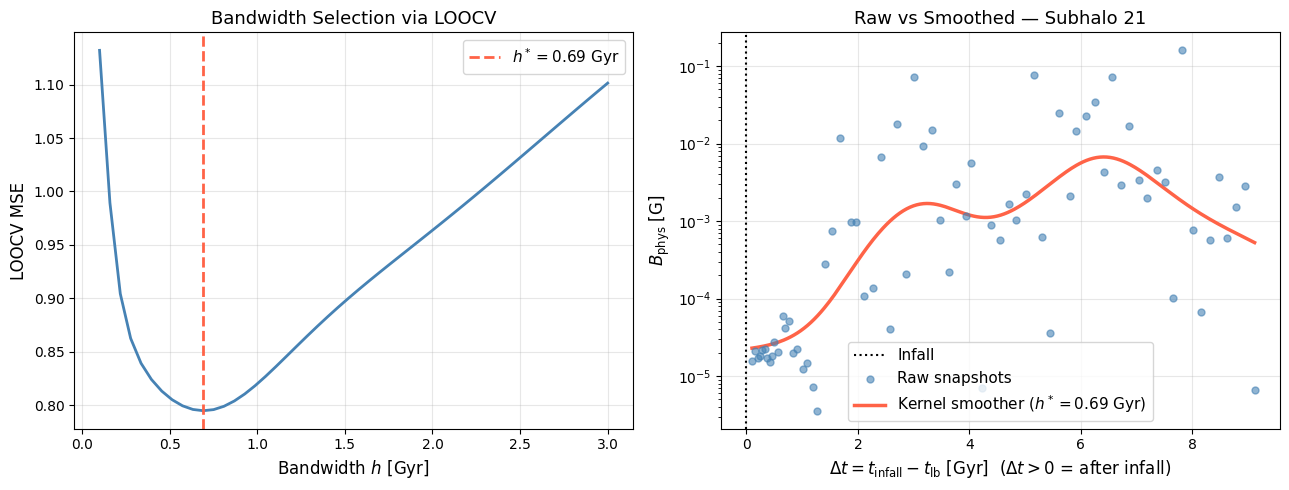

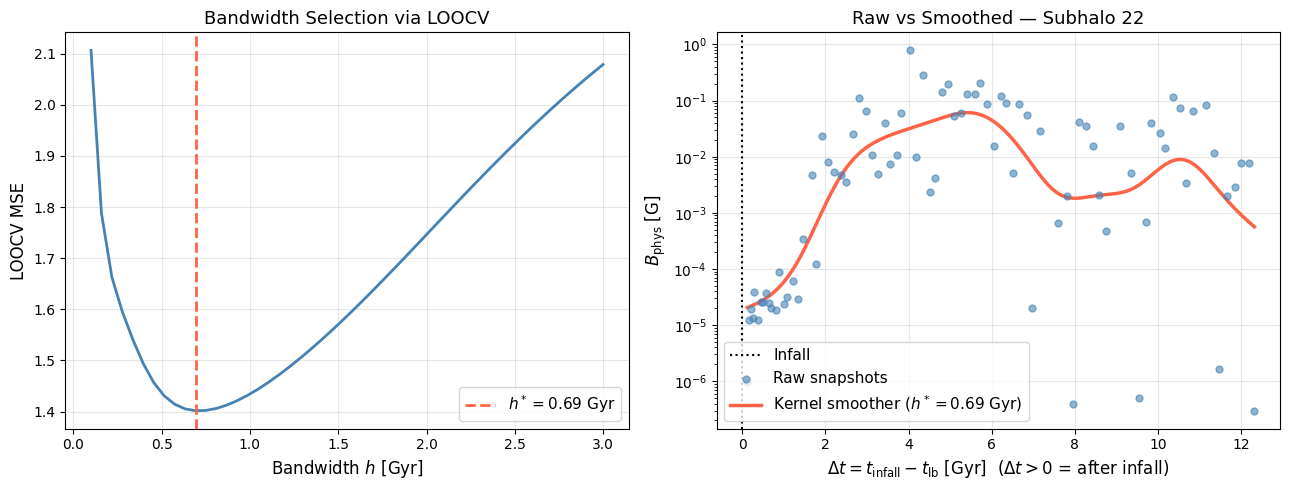

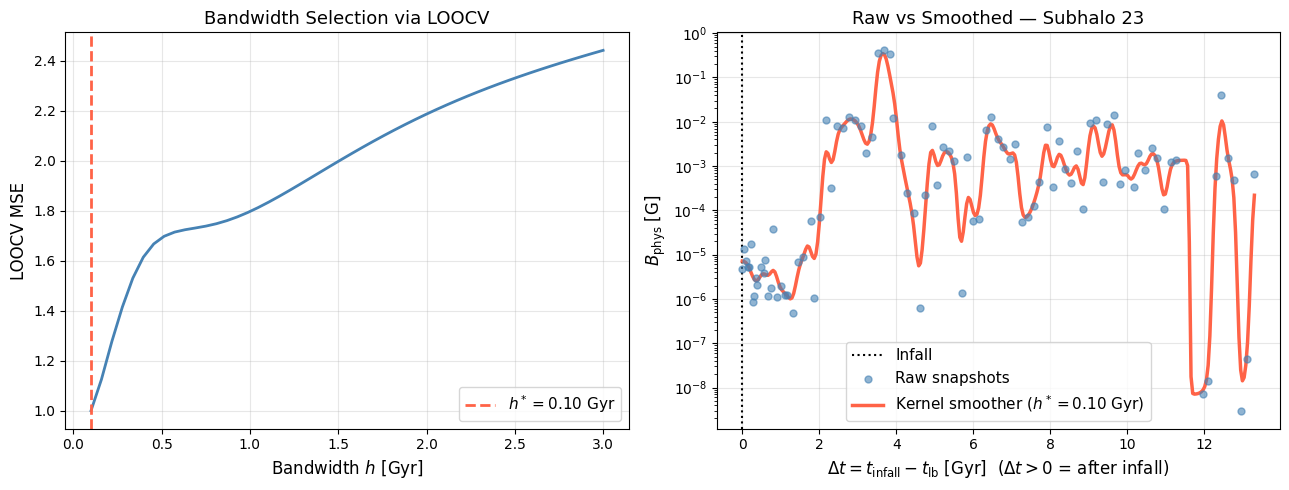

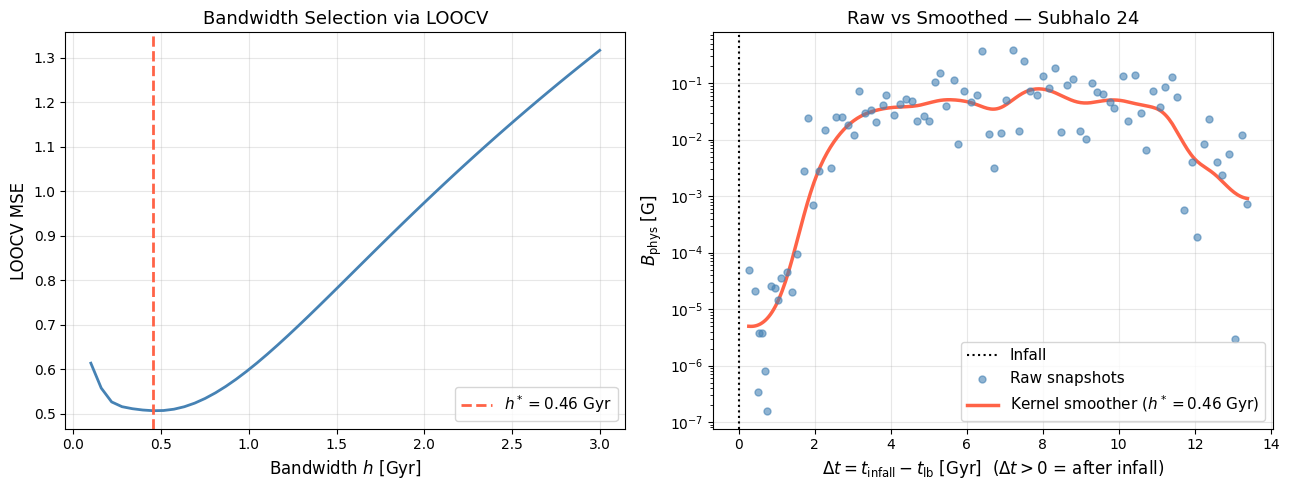

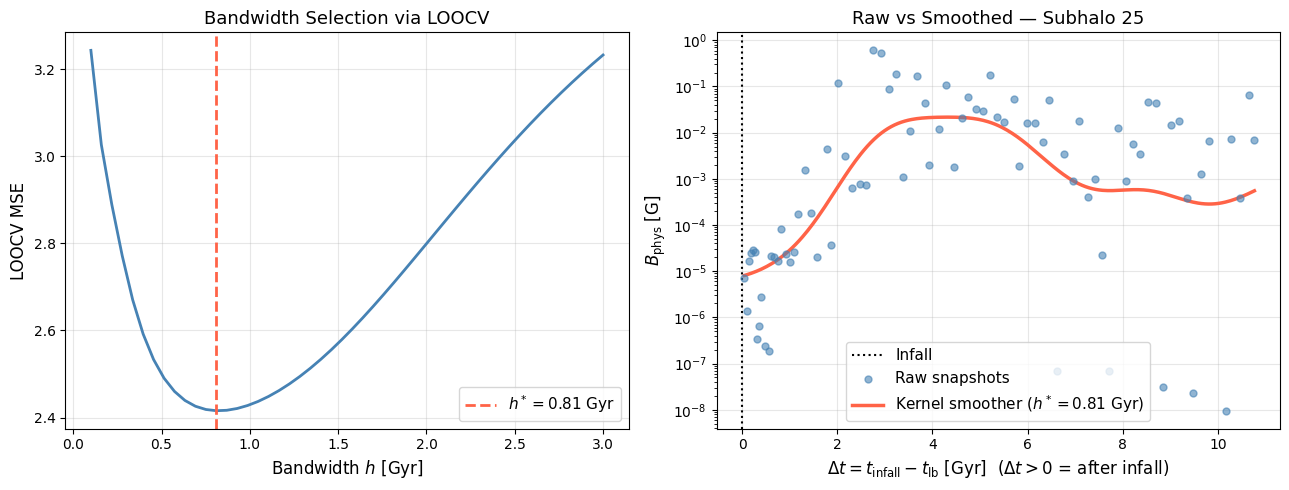

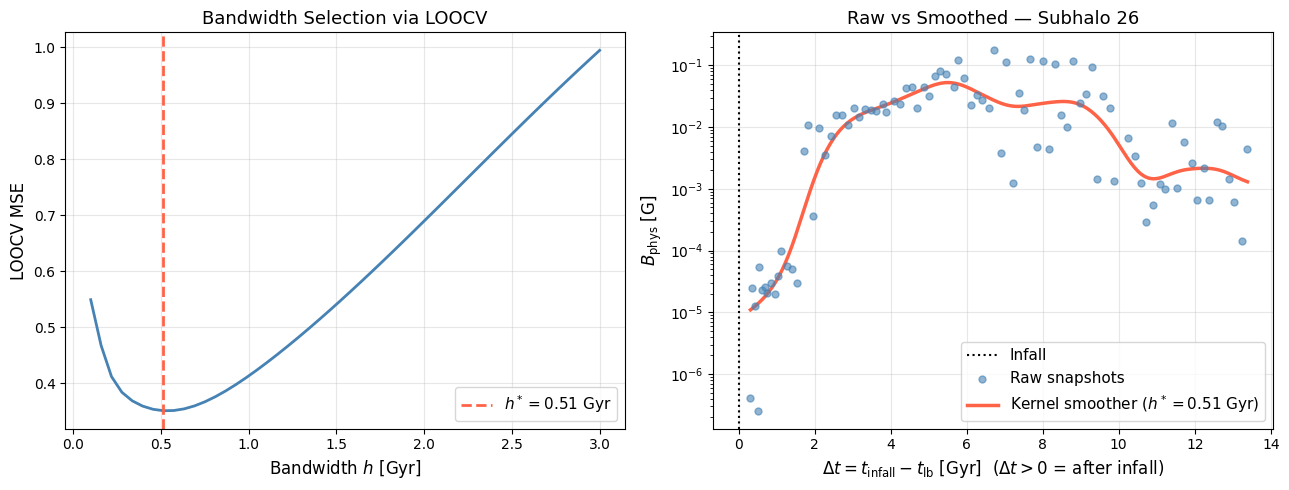

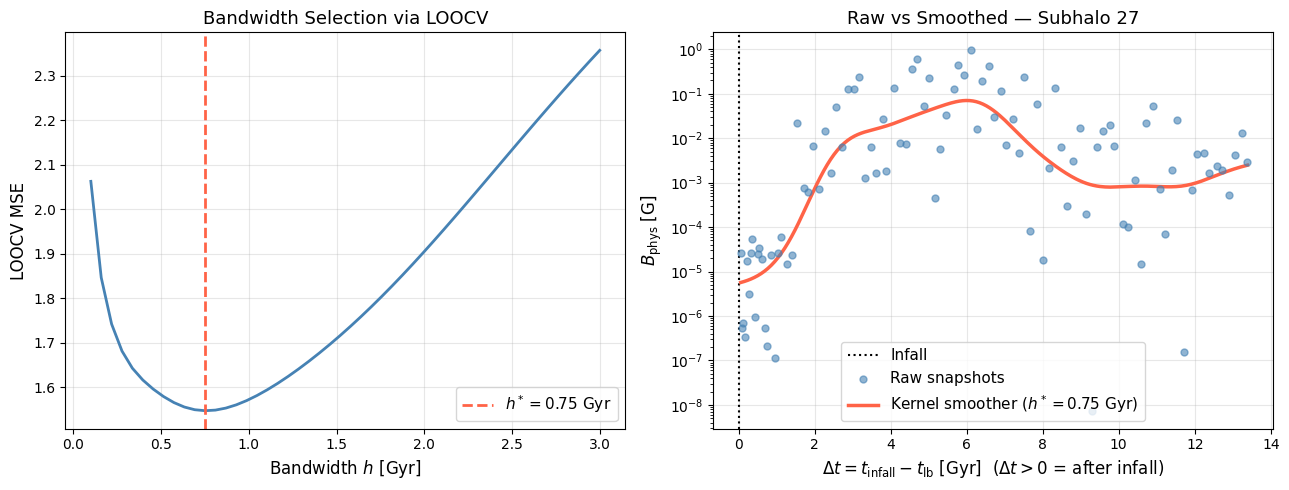

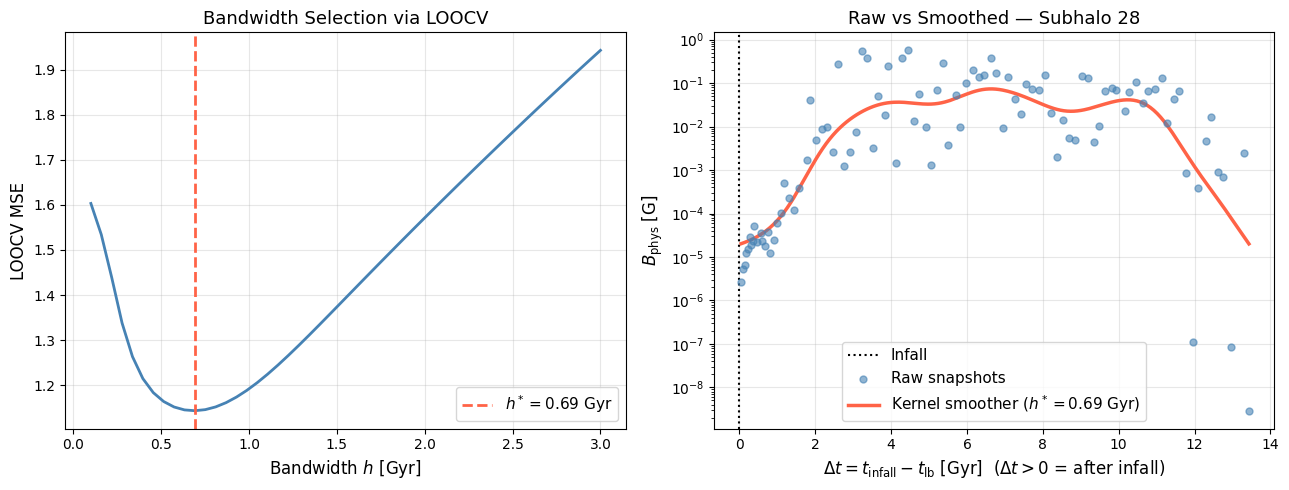

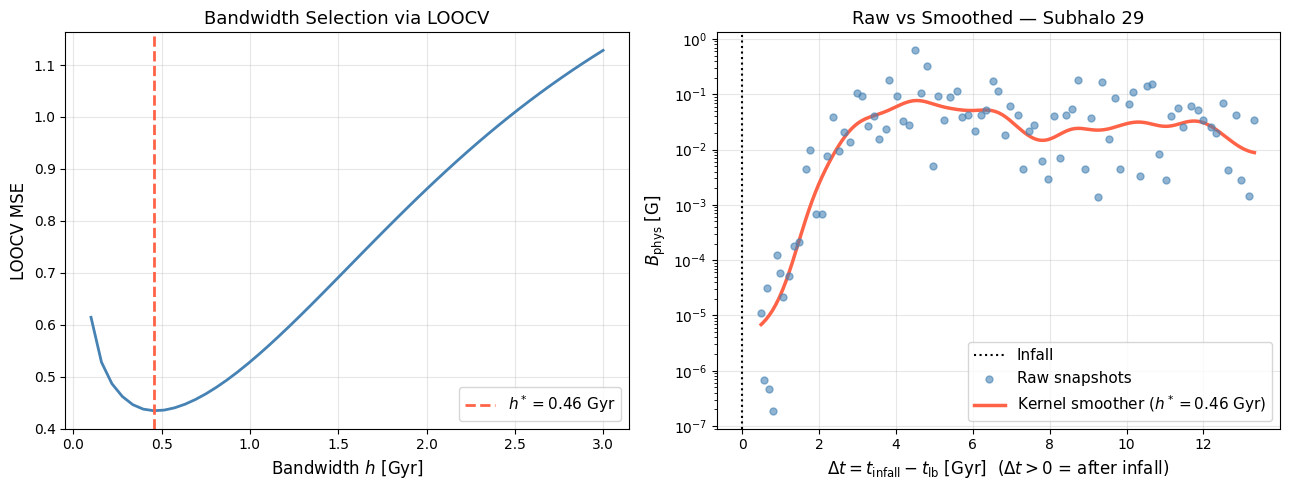

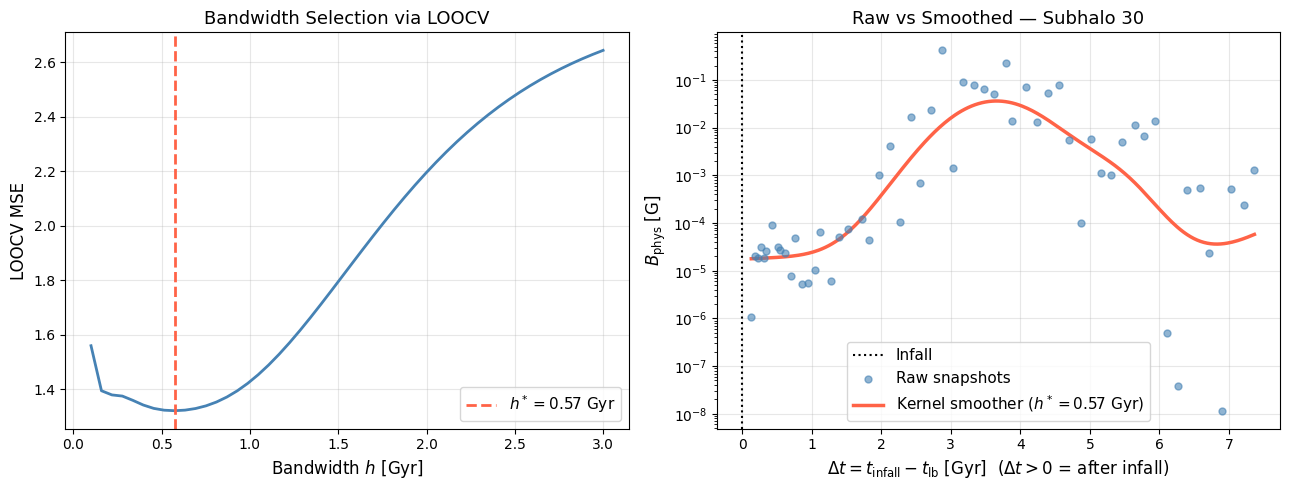

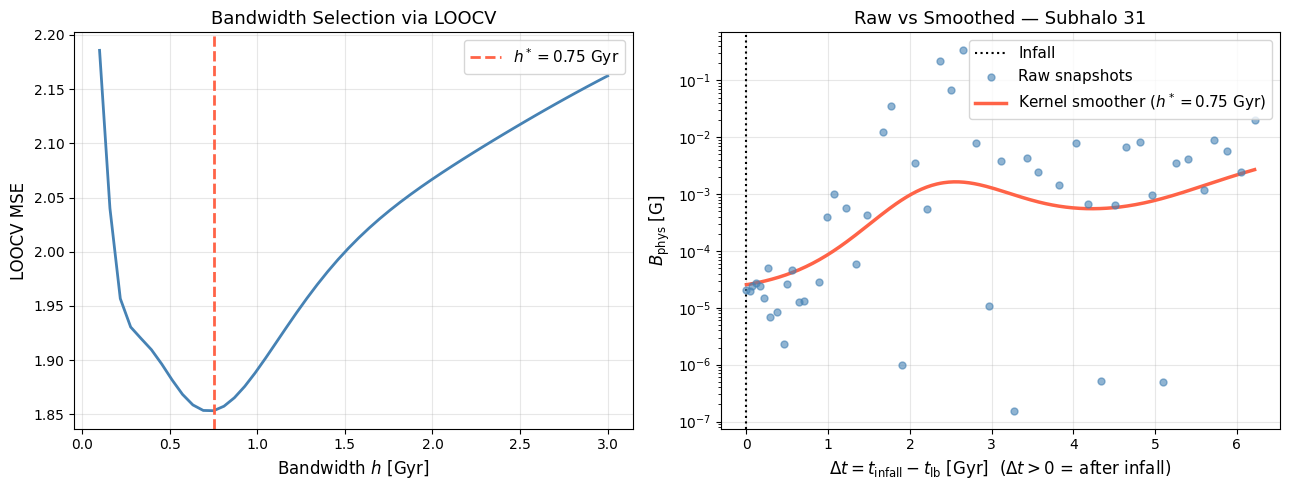

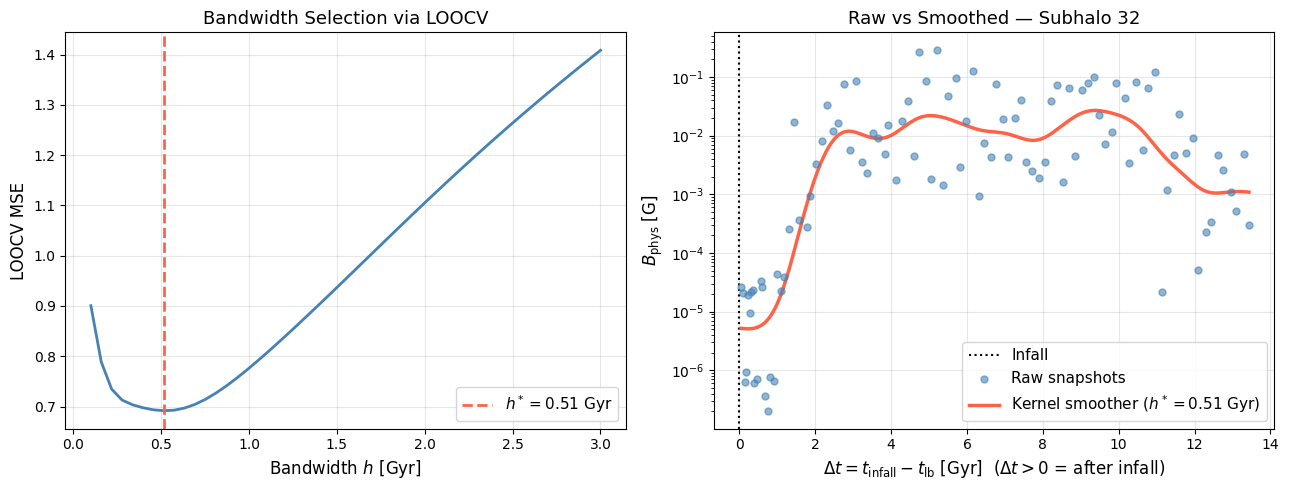

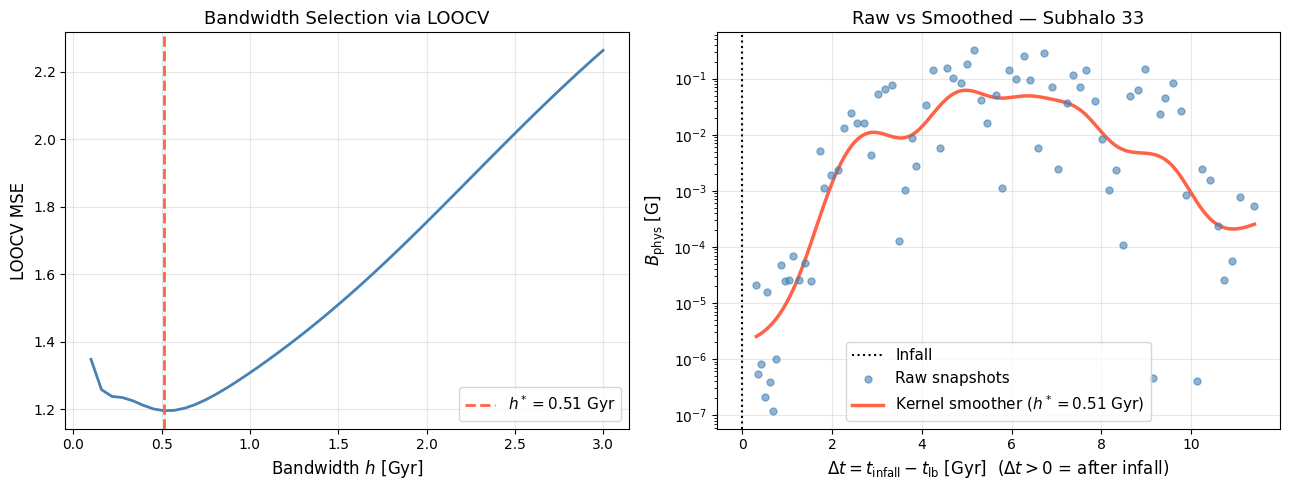

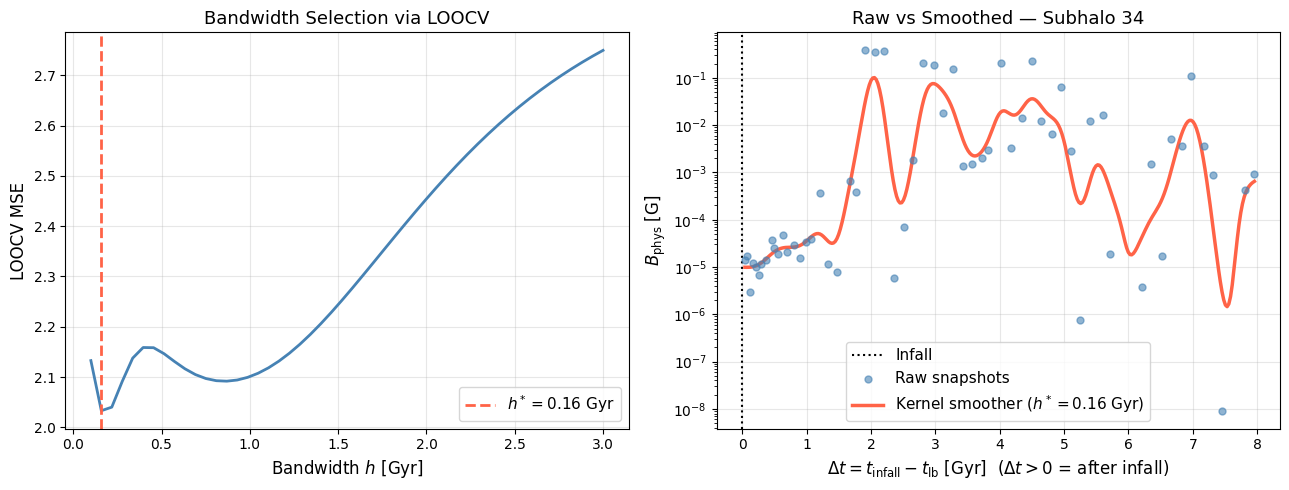

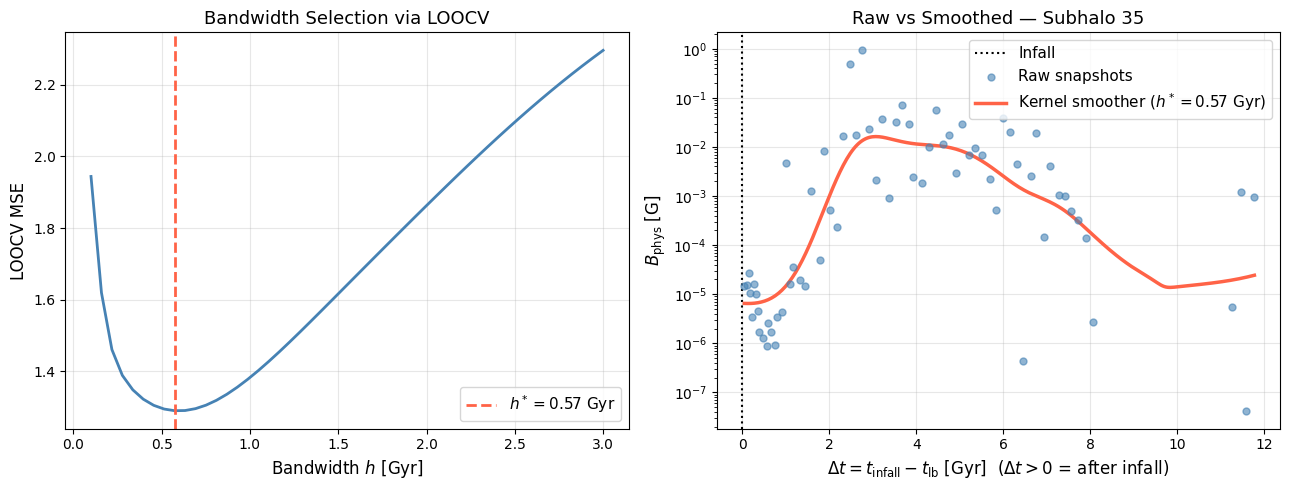

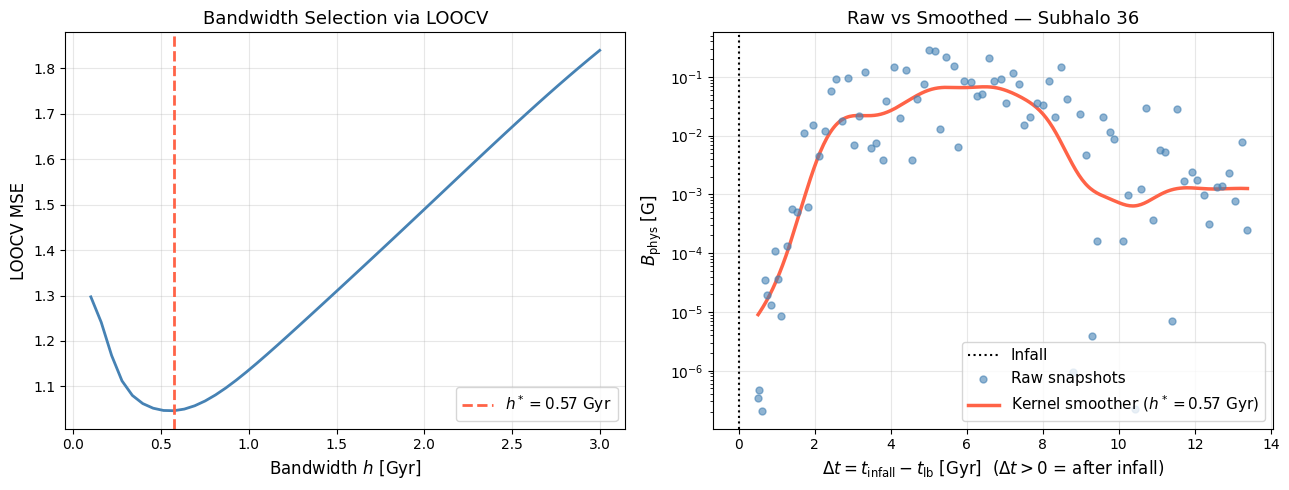

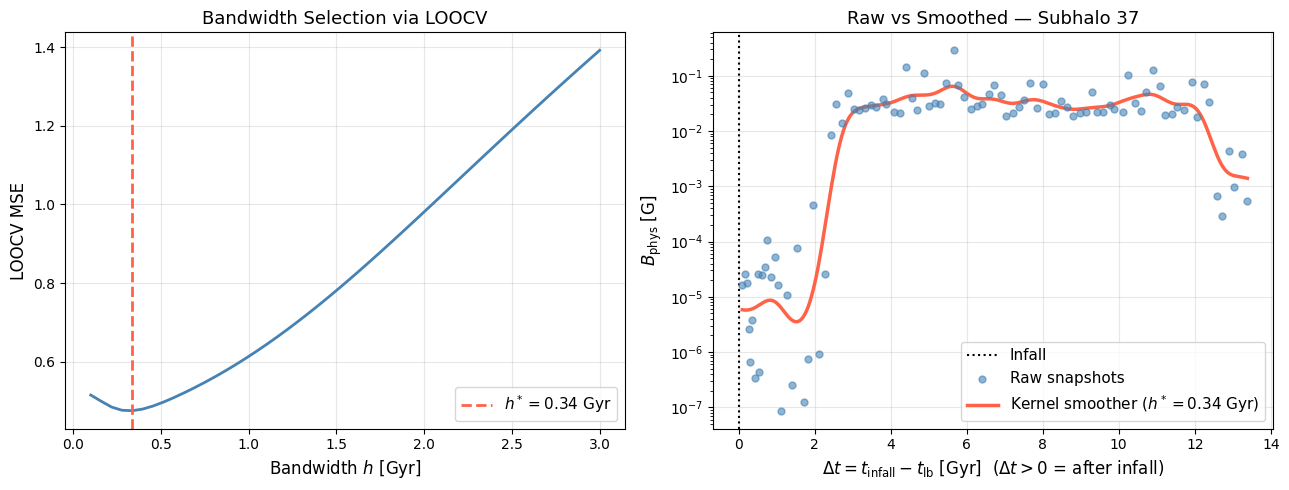

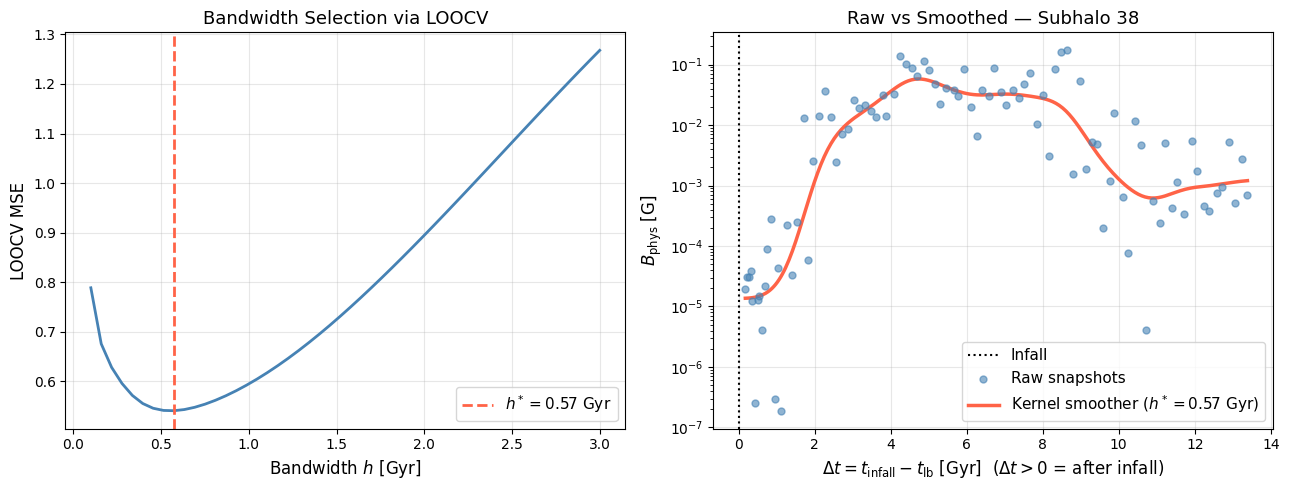

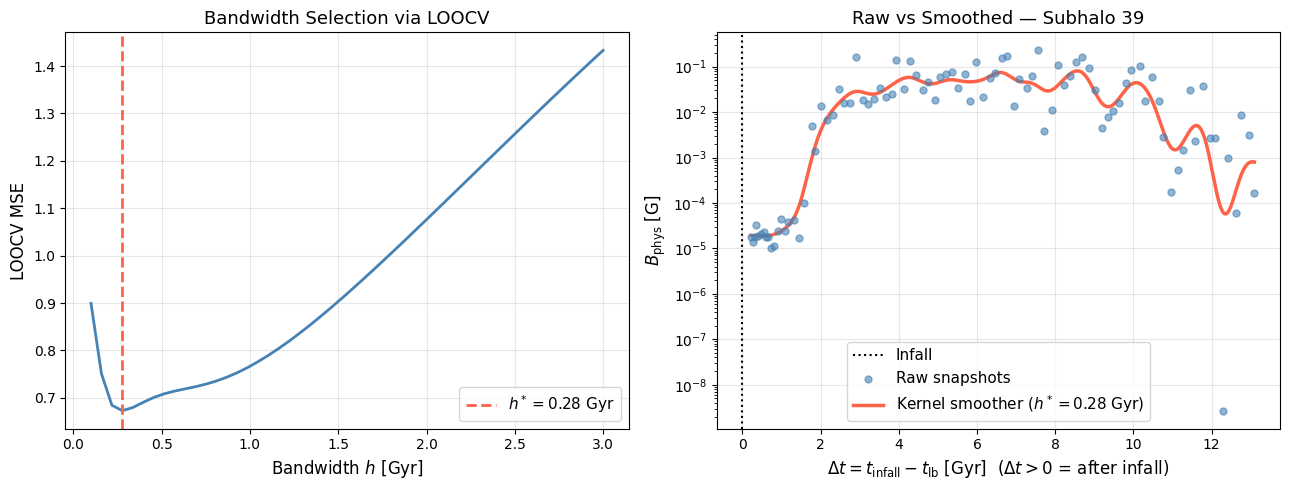

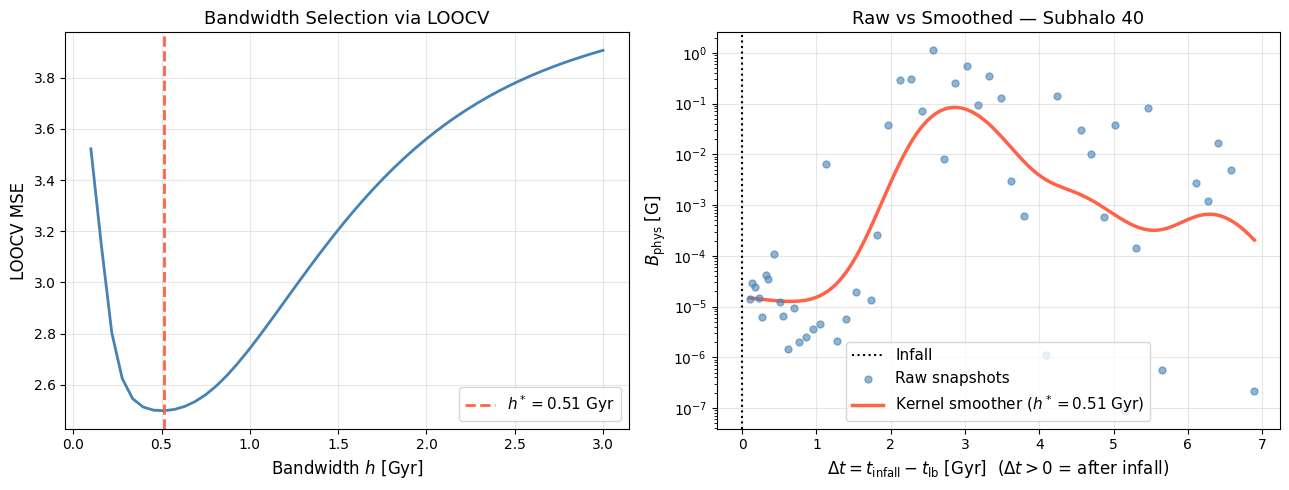

In [ ]:
def smooth_all_galaxies(all_galaxies, field='B_disk_phys'):
    """Apply kernel smoothing + LOOCV to every galaxy in the sample."""
    for i, gal in enumerate(all_galaxies):
        print(f'[{i+1}/{len(all_galaxies)}] Smoothing SubhaloID {gal["subhalo_id"]} ...', end=' ')
        result        = smooth_galaxy(gal['mpb'], gal['infall'], field=field)
        gal['smooth'] = result
        if result:
            print(f'h* = {result["h_opt"]:.2f} Gyr')
        else:
            print('skipped (insufficient data)')
    return all_galaxies


all_galaxies = smooth_all_galaxies(all_galaxies)

# Save updated cache with smoothing results
with open(cache, 'wb') as f:
    pickle.dump(all_galaxies, f)

h_vals = [g['smooth']['h_opt'] for g in all_galaxies if g['smooth']]
print(f"\nSmoothed      : {len(h_vals)} galaxies")
if h_vals:
    print(f"Median h*     : {np.median(h_vals):.2f} Gyr")
    print(f"Range         : {min(h_vals):.2f} - {max(h_vals):.2f} Gyr")

# Plot diagnostics for all galaxies
for gal in all_galaxies:
    plot_smoothing_diagnostics(gal['smooth'], subhalo_id=gal['subhalo_id'])

---
## 9. Smoothed B-field vs Time Since Infall (Key Science Plot)

All smoothed tracks are aligned at $\Delta t = 0$ (infall), where $\Delta t = t_{\rm infall} - t_{\rm lb}$.
Positive $\Delta t$ = after infall. The population median and 16th/84th percentile band summarize the trend.

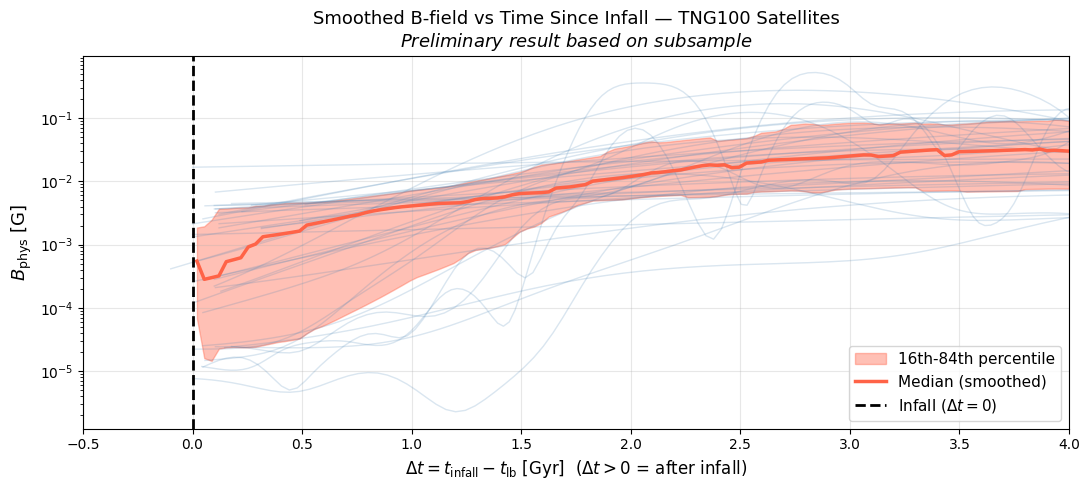

In [ ]:
def plot_smoothed_ensemble(all_galaxies, dt_range=(-6, 4), bin_width=0.5):
    """
    Overlay smoothed B-field tracks aligned at infall, with population median.
    Uses a common time grid to ensure the median aligns with the individual tracks.
    """
    fig, ax = plt.subplots(figsize=(11, 5))

    # Evaluate all smoothed tracks on a single shared grid
    t_common   = np.linspace(dt_range[0], dt_range[1], 300)
    all_B_grid = []

    for gal in all_galaxies:
        s = gal['smooth']
        if s is None or 'dt_fine' not in s:
            continue
        ax.plot(s['dt_fine'], s['B_smooth'], color='steelblue', alpha=0.2, lw=1)
        try:
            f_interp = interp1d(s['dt_fine'], s['B_smooth'],
                                bounds_error=False, fill_value=np.nan)
            all_B_grid.append(f_interp(t_common))
        except Exception:
            continue

    if not all_B_grid:
        print('No smoothed tracks to plot.')
        return

    all_B_grid = np.array(all_B_grid)   # shape (n_galaxies, 300)

    # Median and percentiles — only where at least 3 galaxies have coverage
    median = np.full(300, np.nan)
    p16    = np.full(300, np.nan)
    p84    = np.full(300, np.nan)
    for k in range(300):
        col   = all_B_grid[:, k]
        valid = col[np.isfinite(col)]
        if len(valid) >= 3:
            median[k] = np.median(valid)
            p16[k]    = np.percentile(valid, 16)
            p84[k]    = np.percentile(valid, 84)

    valid_mask = np.isfinite(median)
    ax.fill_between(t_common[valid_mask], p16[valid_mask], p84[valid_mask],
                    alpha=0.4, color='tomato', label='16th-84th percentile')
    ax.plot(t_common[valid_mask], median[valid_mask],
            color='tomato', lw=2.5, label='Median (smoothed)')
    ax.axvline(0, color='black', lw=2, ls='--', label='Infall ($\\Delta t = 0$)')

    ax.set_yscale('log')
    ax.set_xlim(-0.5, 4)
    ax.set_xlabel(r'$\Delta t = t_{\rm infall} - t_{\rm lb}$ [Gyr]  ($\Delta t > 0$ = after infall)', fontsize=12)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=13)
    ax.set_title('Smoothed B-field vs Time Since Infall — TNG100 Satellites\n'
                 r'$\it{Preliminary\ result\ based\ on\ subsample}$', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    #plt.savefig('results/figures/B_smoothed_vs_dt_infall.png', dpi=150)
    plt.savefig(repo_root / f'results/figures/B_vs_z_subhalo_{subhalo_id}.png', dpi=150)
    plt.show()


plot_smoothed_ensemble(all_galaxies)

---
## 10. Fit Exponential Growth to Post-Infall B-field

Following McDonough & Poulin (2025) and the suggestion of the course instructor, we fit a physically motivated saturating growth model to the post-infall ($\Delta t > 0$) smoothed median:

$$B(\Delta t) = B_0\left(1 - e^{-\Delta t / \tau}\right)$$

where $B_0$ is the saturation field strength and $\tau$ is the **amplification timescale** in Gyr. Parameters are estimated via nonlinear least squares (`scipy.optimize.curve_fit`).

Saturation field : B0  = 1.740e-02 +/- 1.542e-03 G
Amplification    : tau = 1.10 +/- 0.64 Gyr


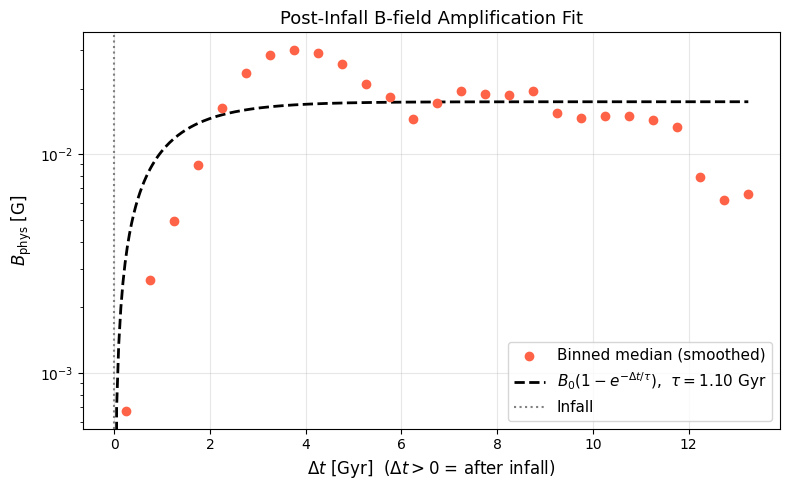

In [ ]:
def exponential_growth(dt, B0, tau):
    """B0 * (1 - exp(-dt/tau)) — saturating growth post-infall."""
    return B0 * (1 - np.exp(-dt / tau))


def fit_single_galaxy(gal):
    """
    Fit B0*(1-exp(-dt/tau)) to one galaxy's smoothed post-infall track.
    Returns (B0, tau, B0_err, tau_err) or None if fit fails.
    """
    s = gal['smooth']
    if s is None or 'dt_fine' not in s:
        return None

    mask = s['dt_fine'] > 0
    x = s['dt_fine'][mask]
    y = s['B_smooth'][mask]

    if len(x) < 3:
        return None

    try:
        popt, pcov = curve_fit(exponential_growth, x, y,
                               p0=[y.max(), 2.0],
                               bounds=([0, 0.1], [np.inf, 20]),
                               maxfev=5000)
        perr = np.sqrt(np.diag(pcov))
        return {'B0': popt[0], 'tau': popt[1],
                'B0_err': perr[0], 'tau_err': perr[1],
                'subhalo_id': gal['subhalo_id']}
    except RuntimeError:
        return None


def fit_all_and_plot_distributions(all_galaxies):
    """
    Fit exponential to each galaxy individually.
    Plot distributions of B0 and tau across the sample.
    """
    fits = []
    for gal in all_galaxies:
        result = fit_single_galaxy(gal)
        if result:
            fits.append(result)
            print(f"SubhaloID {result['subhalo_id']:>8d} :  "
                  f"tau = {result['tau']:.2f} +/- {result['tau_err']:.2f} Gyr  |  "
                  f"B0 = {result['B0']:.3e} G")
        else:
            print(f"SubhaloID {gal['subhalo_id']:>8d} :  fit failed or insufficient data")

    if not fits:
        print('No successful fits.')
        return

    taus = [f['tau']    for f in fits]
    B0s  = [f['B0']     for f in fits]
    ids  = [f['subhalo_id'] for f in fits]

    print(f'\nMedian tau : {np.median(taus):.2f} Gyr')
    print(f'Mean tau   : {np.mean(taus):.2f} Gyr')
    print(f'Std tau    : {np.std(taus):.2f} Gyr')

    # Plot 1: distribution of timescales tau
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.hist(taus, bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    ax1.axvline(np.median(taus), color='tomato', lw=2, ls='--',
                label=f'Median = {np.median(taus):.2f} Gyr')
    ax1.set_xlabel(r'Amplification timescale $\tau$ [Gyr]', fontsize=12)
    ax1.set_ylabel('Number of galaxies', fontsize=12)
    ax1.set_title(r'Distribution of $\tau$ — SubhaloGrNr = 0', fontsize=13)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Plot 2: distribution of saturation field strength B0
    ax2.hist(np.log10(B0s), bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(np.median(np.log10(B0s)), color='tomato', lw=2, ls='--',
                label=f'Median = {np.median(np.log10(B0s)):.2f}')
    ax2.set_xlabel(r'$\log_{10}(B_0\,[\mathrm{G}])$', fontsize=12)
    ax2.set_ylabel('Number of galaxies', fontsize=12)
    ax2.set_title(r'Distribution of $B_0$ — SubhaloGrNr = 0', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/figures/tau_B0_distributions.png', dpi=150)
    plt.show()

    # Plot 3: individual smoothed tracks + their fits overlaid
    fig, ax = plt.subplots(figsize=(11, 5))
    for f in fits:
        gal = next(g for g in all_galaxies if g['subhalo_id'] == f['subhalo_id'])
        s   = gal['smooth']
        mask = s['dt_fine'] > 0
        ax.plot(s['dt_fine'][mask], s['B_smooth'][mask],
                color='steelblue', alpha=0.3, lw=1)
        t_fine = np.linspace(0, s['dt_fine'][mask].max(), 200)
        ax.plot(t_fine, exponential_growth(t_fine, f['B0'], f['tau']),
                color='tomato', alpha=0.4, lw=1.5, ls='--')

    ax.set_yscale('log')
    ax.set_xlabel(r'$\Delta t$ [Gyr]  ($\Delta t > 0$ = after infall)', fontsize=12)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=12)
    ax.set_title('Individual Smoothed Tracks + Exponential Fits\n'
                 'SubhaloGrNr = 0 satellites', fontsize=13)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/figures/individual_fits_grnr0.png', dpi=150)
    plt.show()

    return fits


fits = fit_all_and_plot_distributions(all_galaxies)

---
## Notes

### Caching
`iapi.gettree()` saves HDF5 files to `trees/` automatically. Processed results are cached to `data/processed/all_galaxies.pkl` so you can reload without re-querying the API:
```python
with open('data/processed/all_galaxies.pkl', 'rb') as f:
    all_galaxies = pickle.load(f)
```

### 403 errors
If a subhalo returns a 403, the code prints the URL to check in your browser. `process_all_satellites()` automatically skips failed downloads.

### Scaling up
Change `limit=40` in `query_satellites()` to 100-500 for the final analysis. Delete the cache file first so it re-downloads fresh data:
```python
os.remove('data/processed/all_galaxies.pkl')
```